# Safe Parking Need Analysis

*UP213 Urban Data Science (2025 Spring) Group Project*

#### **Group Members:** Simon Han, Tomohiro Ujikawa  

## Objective 
To identify where vehicle homelessness is concentrated in Los Angeles, and to assess underused parking garages that could help meet the need for safe overnight parking.

## Background  
Vehicle residency is on the rise among working-class individuals and families as housing costs continue to outpace wages in LA. While permanent housing remains the long-term goal, the shortage of affordable units and the time and cost required to build them has created an urgent need for **immediate, interim solutions**.

Safe parking programs, which provide a legal place to sleep in one’s vehicle along with access to restrooms and services, are one such solution. Many city-owned parking garages in LA sit largely empty during overnight hours and could be repurposed to support these programs. This project analyzes both the **concentration of vehicle homelessness** and the **potential of underused city-owned garages** to serve as safe parking sites.

## Key Questions  
- Where is **vehicle homelessness concentrated** in Los Angeles?  
- Which **underused parking garages** could be matched with areas of high need for safe parking?

#### **Dataset:**
Safe Parking **Needs**: 
- LAHSA Homeless Count: vehicle dwelling counts by tract
- ACS: poverty, rent burden, vehicle ownership, housing overcrowding

Potential **Supply**:  
- ParkMe (real-time occupancy data for Santa Monica)  
- City of LA Parking Garage Locations and Characteristics  
- Supplemental: Zoning, transit access, and service proximity (for refining site viability)

#### **Method:**
- **Data Scraping** for real-time or web-only garage data 
- **Spatial Joins** to overlay homelessness data with garage locations
- **Machine Learning** to predict unmet safe parking need using ACS features 
- **Overlay Analysis** to identify garage locations that could meet the predicted need

In [1]:
import os
import pandas as pd
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
import requests
import numpy as np

os.getcwd()

'/Users/Tomo/Desktop/UP213_group/archive'

### Tiger/Lines

##### Importing Tiger Lines & sorting LA county for 2020-24 years

In [2]:
drop_geoids = ['06037990100', '06037990200', '06037990300']

for year in range(2019, 2025):
    path = f"../Data/tl_shp_library/tl_{year}_06_tract.zip"
    tracts = gpd.read_file(path)
    la_tracts = tracts[(tracts["COUNTYFP"] == "037") & (tracts["STATEFP"] == "06")]
    la_tracts = la_tracts.set_index('GEOID')
    la_tracts = la_tracts.drop(index=drop_geoids, errors='ignore')
    
    var_name = f"tracts{str(year)[-2:]}"
    globals()[var_name] = la_tracts

now we have Tiger/Line GDFs named (tracts19, tracts20, tracts21, .., tracts24)

##### checking the proportion of indentical data

In [3]:
# #checking the proportion of indentical data between 2020 and 24
# #getting index as set
# index_20 = set(tracts20.index)
# index_24 = set(tracts24.index)

# #counting the shared GEOIDs
# common_geoids = index_20 & index_24
# num_common = len(common_geoids)

# #counting the GEOID of each dataframe
# num_2020 = len(index_20)
# num_2024 = len(index_24)

# #calculating the matching ratio
# match_rate_2020 = num_common / num_2020
# match_rate_2024 = num_common / num_2024
# print(match_rate_2020)
# print(match_rate_2024)

confirmed Tiger/line in 2020 and 24 have the same GEOIDs

In [4]:
# #checking the proportion of indentical data between 2019 and 20
# #getting index as set
# index_19 = set(tracts19.index)
# index_20 = set(tracts20.index)

# #counting the shared GEOIDs
# common_geoids = index_19 & index_20
# num_common = len(common_geoids)

# #counting the GEOID of each dataframe
# num_2019 = len(index_19)
# num_2020 = len(index_20)

# #calculating the matching ratio
# match_rate_2019 = num_common / num_2019
# match_rate_2020 = num_common / num_2020
# print(match_rate_2019)
# print(match_rate_2020)

confirmed there are 14% discrepancy between 2019 and 2020 Tiger/lines

### Landuse data: SCAG 2019 Regional Land Use dataset (May 2023 Ver.)

##### downloading data
https://hub.scag.ca.gov/datasets/3e9c888c6aae45ab8e140abeec42cd1e_0/about

In [5]:
# by using downloaded data instead of API
# luGdf = gpd.read_file("Data/landuse.gpkg")

In [6]:
import zipfile

with zipfile.ZipFile("../Data/landuse.gpkg.zip", 'r') as zip_ref:
    zip_ref.extractall("../Data/")
luGdf = gpd.read_file("../Data/landuse.gpkg")

/opt/anaconda3/envs/uds/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: This version of GeoPackage user_version=0x000028A0 (10400, v1.4.0) on '../Data/landuse.gpkg' may only be partially supported
  return ogr_read(
/opt/anaconda3/envs/uds/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column YEAR_GP, 2015-05-01T00:00:00.0Z, successfully parsed
  return ogr_read(


In [7]:
# selecting columns to use
selected_cols = ['ACRES', 'GEOID20', 'DEN_AVG', 'ZN19_SCAG', 'LU19', 'geometry']
luGdf = luGdf[selected_cols]

In [8]:
# len(luGdf)
# # we have the option of using API, but the size is not reasonable to use API

##### Making column of major categories

In [9]:
luGdf['LU19'] = pd.to_numeric(luGdf['LU19'], errors='coerce')

lu19_major_categories = {
    1100: "Residential",
    1200: "Commercial and Services",
    1300: "Industrial",
    1400: "Transportation, Communications, and Utilities",
    1500: "Public Facilities",
    1600: "Open Space and Recreation",
    1700: "Vacant",
    1800: "Water",
    1900: "Agriculture",
    8888: "Undevelopable or Protected Land",
    9999: "LandUnknown"
}

luGdf['LU19_major_code'] = (luGdf['LU19'] // 100) * 100
luGdf.loc[luGdf['LU19'] == 8888, 'LU19_major_code'] = 8888
luGdf.loc[luGdf['LU19'] == 9999, 'LU19_major_code'] = 9999

luGdf['LU19_major_label'] = luGdf['LU19_major_code'].map(lu19_major_categories)

#### Mapping the destribution of major landuse categories

In [10]:
# import matplotlib.pyplot as plt
# import contextily as ctx

# luGdf_map = luGdf.to_crs(epsg=3857)
# fig, ax = plt.subplots(figsize=(12, 10))

# luGdf_map.plot(
#     column="LU19_major_label",
#     cmap="Set3",
#     legend=True,
#     ax=ax,
#     alpha=0.9)

# # drop Catalina
# ax.set_ylim([3.98e6, 4.14e6])
# ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=12)

# # and we really don't need the axis ticks and labels, so we set them to an empty list
# ax.set_xticks([])
# ax.set_yticks([])

# plt.title("Land Use Categories (SCAG LU19 Major Labels)")
# plt.axis("off")
# plt.tight_layout()
# plt.show()

#### Calculating the proportion of landuse type for each tract

In [11]:
# making column of GEOID by using the first 11 digit out of 15 digit(block level)
luGdf['GEOID'] = luGdf['GEOID20'].str[:11]

In [12]:
# converting the gdf into meter based projection
luGdf_proj = luGdf.to_crs(epsg=3497)

# making a column that shows the area of each parcel
luGdf_proj['area_m2'] = luGdf_proj.geometry.area

In [13]:
# calculating the area of each landuse type for each tract
# tract_lu has rows that shows the area of each landuse type for each tract (one tract has a couple of rows for each landuse type)
tract_lu = luGdf_proj.groupby(['GEOID', 'LU19_major_label'])['area_m2'].sum().reset_index()

In [14]:
# calculating the total area for each tract and name it tract_total
tract_total = tract_lu.groupby('GEOID')['area_m2'].sum().reset_index(name='total_area_m2')

In [15]:
# calculating the proportion of each land use type for each census tract
tract_lu = tract_lu.merge(tract_total, on='GEOID')
tract_lu['percent'] = tract_lu['area_m2'] / tract_lu['total_area_m2'] * 100

#### Calculating the proportion of residential use area for each tract

In [16]:
# extracting the rows with "Residential"
tract_residential = tract_lu[tract_lu['LU19_major_label'] == 'Residential'][['GEOID', 'percent']]
tract_residential = tract_residential.rename(columns={'percent': 'pct_residential'})

##### Mapping (by using tract23)

In [17]:
tract_residential = tract_residential.set_index("GEOID")
tract_residential = tracts23.join(tract_residential, how="left")

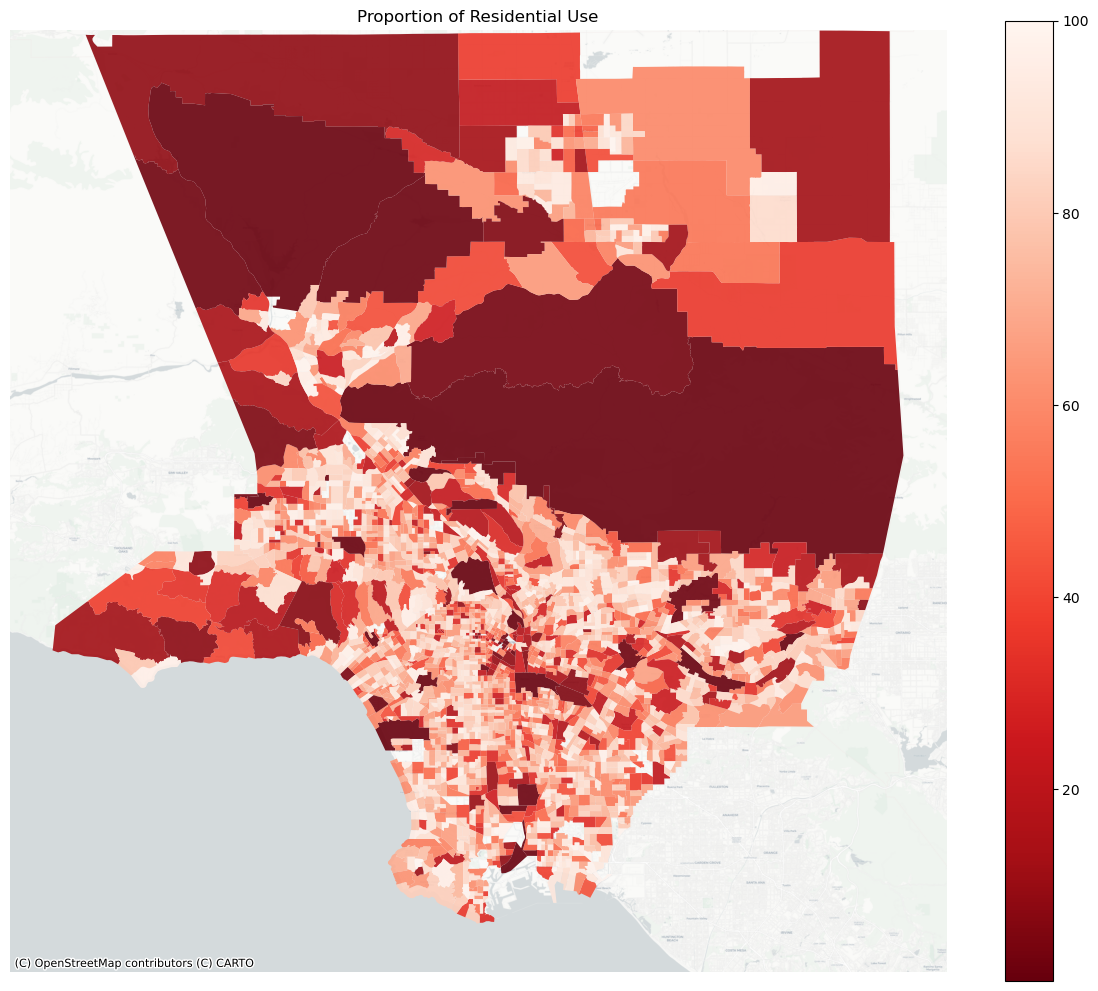

In [18]:
import contextily as ctx
import matplotlib.pyplot as plt

tract_residential_map = tract_residential.to_crs(epsg=3857)
fig, ax = plt.subplots(figsize=(12, 10))

tract_residential_map.plot(
    column='pct_residential',
    cmap='Reds_r', 
    legend=True,
    ax=ax,
    alpha=0.9)

# drop Catalina
ax.set_ylim([3.98e6, 4.14e6])
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=12)

# and we really don't need the axis ticks and labels, so we set them to an empty list
ax.set_xticks([])
ax.set_yticks([])

plt.title("Proportion of Residential Use")
plt.axis("off")
plt.tight_layout()
plt.show()

### making buffer polygons for each tract (2000m)

In [19]:
tracts23_buffer = tracts23.to_crs(epsg=3497)
tracts23_buffer["geometry"] = tracts23_buffer.buffer(2000)

### Amenities data

##### importing data of public facilities

Data source: https://geohub.lacity.org/maps/c5a91c789041455485de39a45d0aae0c/about

In [20]:
ArtsRecreation = gpd.read_file("../data/public_facilities/ArtsRecreation.gpkg").to_crs(epsg=3497)
Education = gpd.read_file("../data/public_facilities/Education.gpkg").to_crs(epsg=3497)
Hospitals = gpd.read_file("../data/public_facilities/Hospitals.gpkg").to_crs(epsg=3497)
MunicipalServices = gpd.read_file("../data/public_facilities/MunicipalServices.gpkg").to_crs(epsg=3497)
PhysicalFeatures = gpd.read_file("../data/public_facilities/PhysicalFeatures.gpkg").to_crs(epsg=3497)
PublicSafety = gpd.read_file("../data/public_facilities/PublicSafety.gpkg").to_crs(epsg=3497)
Transportation = gpd.read_file("../data/public_facilities/Transportation.gpkg").to_crs(epsg=3497)

/opt/anaconda3/envs/uds/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: This version of GeoPackage user_version=0x000028A0 (10400, v1.4.0) on '../data/public_facilities/ArtsRecreation.gpkg' may only be partially supported
  return ogr_read(
/opt/anaconda3/envs/uds/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: This version of GeoPackage user_version=0x000028A0 (10400, v1.4.0) on '../data/public_facilities/Education.gpkg' may only be partially supported
  return ogr_read(
/opt/anaconda3/envs/uds/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column last_update, 2025-03-10T00:00:00.0Z, successfully parsed
  return ogr_read(
/opt/anaconda3/envs/uds/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: This version of GeoPackage user_version=0x000028A0 (10400, v1.4.0) on '../data/public_facilities/Hospitals.gpkg' may only be partially supported
  return ogr_read(
/opt/anaconda3/envs/uds/l

##### Dropping irrelevant rows (such as jails in PublicSafety)

In [21]:
PublicSafety = PublicSafety[~PublicSafety["cat2"].isin([
    "Jails and Prisons",
    "Probation Camps and Juvenile Halls"
])].reset_index(drop=True)

##### importing data of food pantries

In [22]:
pantryDf = pd.read_csv('../data/Food_Resources_in_California.csv')

#extracting data of LA county
pantryDf = pantryDf[pantryDf.County=='Los Angeles']

#changing the dataframe into geodataframe
Pantry = gpd.GeoDataFrame(
    pantryDf, geometry=gpd.points_from_xy(pantryDf.Longitude, pantryDf.Latitude, 
                                          crs='EPSG:4326'))
Pantry = Pantry.to_crs(epsg=3497)

##### importing data of public parkings (SCAG 2019)

In [23]:
Parking = luGdf[luGdf['LU19'] == 1247]
Parking = Parking.to_crs(epsg=3497)

In [24]:
Parking = Parking.set_index('GEOID')

##### Mapping number of public parkings (point data)

In [25]:
# changing the geometry of parkings from polygon(parcel) to point(centroid)
Parking['geometry'] = Parking.centroid

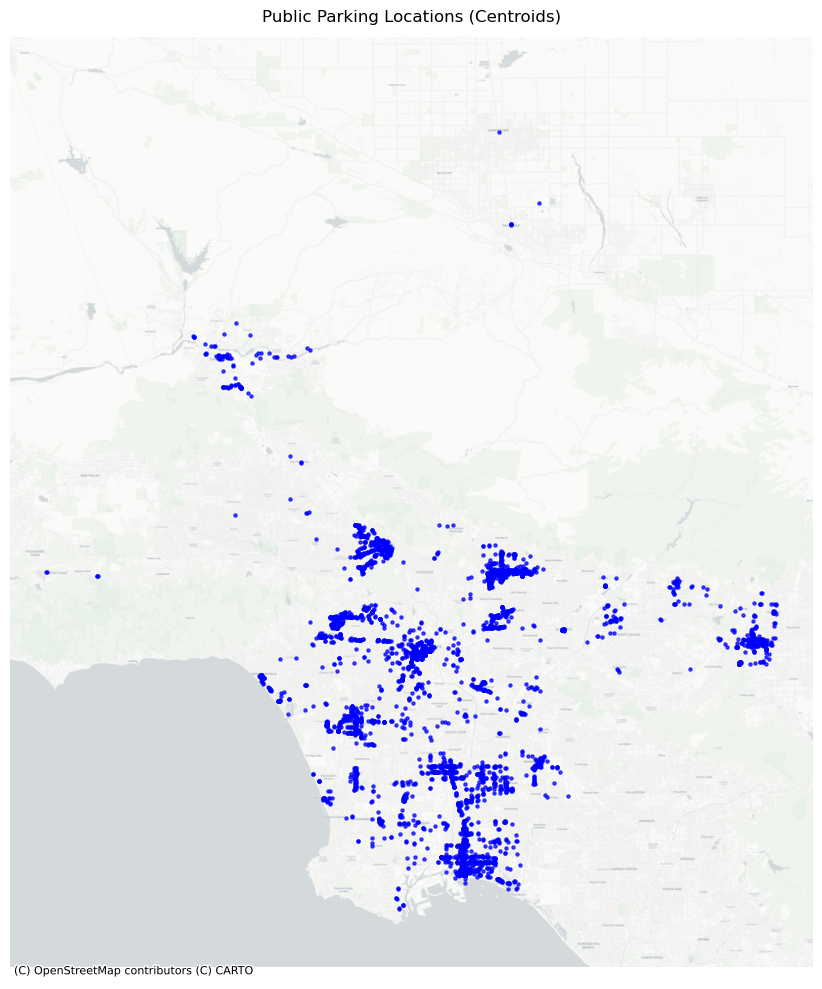

In [26]:
Parking_web = Parking.to_crs(epsg=3857)
fig, ax = plt.subplots(figsize=(12, 10))

Parking_web.plot(
    ax=ax,
    color='blue',
    markersize=5,
    alpha=0.7
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=12)

ax.set_ylim([3.98e6, 4.14e6])
ax.set_xticks([])
ax.set_yticks([])
plt.title("Public Parking Locations (Centroids)")
plt.axis("off")
plt.tight_layout()
plt.show()

##### Joining public facilities, pantry data, and parking data with tract polygons (buffered)

In [27]:
#Codes for individual procedure
# spatial join
#tmpgdf_ms = gpd.sjoin(tracts23_buffer, MunicipalServices, predicate='intersects')

# group by
#MunicipalServices_counts = tmpgdf_ms.groupby('GEOID').size()
#MunicipalServices_counts.name = 'n_MunicipalServices'

# join back
#tracts23_buffer = tracts23_buffer.join(MunicipalServices_counts)
#tracts23_buffer.fillna({'n_MunicipalServices':0}, inplace=True)
#tracts23_buffer.n_MunicipalServices.describe()

In [28]:
#Codes using function
def count_facilities_within_tracts(tracts_gdf, points_gdf, buffer_gdf_name):
    tmp = gpd.sjoin(tracts_gdf, points_gdf, predicate='intersects')

    # counting facilities for each polygon
    counts = tmp.groupby('GEOID').size()
    counts.name = f'n_{buffer_gdf_name}'

    # join with original polygon
    tracts_gdf = tracts_gdf.join(counts)

    # filling NaN with 0
    tracts_gdf.fillna({f'n_{buffer_gdf_name}': 0}, inplace=True)

    return tracts_gdf

In [29]:
tracts23_buffer = count_facilities_within_tracts(tracts23_buffer, ArtsRecreation, 'ArtsRecreation')
tracts23_buffer = count_facilities_within_tracts(tracts23_buffer, Education, 'Education')
tracts23_buffer = count_facilities_within_tracts(tracts23_buffer, Hospitals, 'Hospitals')
tracts23_buffer = count_facilities_within_tracts(tracts23_buffer, MunicipalServices, 'MunicipalServices')
tracts23_buffer = count_facilities_within_tracts(tracts23_buffer, PhysicalFeatures, 'PhysicalFeatures')
tracts23_buffer = count_facilities_within_tracts(tracts23_buffer, PublicSafety, 'PublicSafety')
tracts23_buffer = count_facilities_within_tracts(tracts23_buffer, Transportation, 'Transportation')
tracts23_buffer = count_facilities_within_tracts(tracts23_buffer, Pantry, 'Pantry')

In [30]:
tracts23_buffer = tracts23_buffer.reset_index()

In [31]:
tmpgdf_ms = gpd.sjoin(tracts23_buffer, Parking, predicate='intersects')

Parking_counts = tmpgdf_ms.groupby('GEOID_left').size()
Parking_counts.name = 'n_Parking'

tracts23_buffer = tracts23_buffer.set_index('GEOID').join(Parking_counts).reset_index()
tracts23_buffer['n_Parking'] = tracts23_buffer['n_Parking'].fillna(0).astype(int)

##### moving all data in tracts23_buffer into tracts23

In [32]:
tracts23_geom = tracts23.reset_index().to_crs(epsg=3497)[['GEOID', 'geometry']]
tracts23 = tracts23_buffer.drop(columns='geometry').merge(tracts23_geom, on='GEOID')

In [33]:
tracts23 = tracts23.set_index('GEOID')
tracts23 = gpd.GeoDataFrame(tracts23, geometry='geometry', crs='EPSG:3497')

##### Mapping number of public parkings (aggregated at tract)

In [34]:
# import contextily as ctx

# tracts23_web = tracts23.to_crs(epsg=3857)
# fig, ax = plt.subplots(figsize=(12, 10))

# tracts23_web.plot(
#     column='n_Parking',
#     cmap='OrRd',
#     legend=True,
#     ax=ax,
#     alpha=0.6)

# # drop Catalina
# ax.set_ylim([3.98e6, 4.14e6])

# ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=12)

# ax.set_xticks([])
# ax.set_yticks([])
# plt.title("Number of Parking Parcels within 2000m of Each Census Tract")
# plt.axis("off")
# plt.tight_layout()
# plt.show()

### LAHSA data

##### merging split rows (2022, 2023, 2024)

In [35]:
#defining non-merging columns
representative_cols = ['year', 'lacity', 'spa', 'sd', 'cd', 'ca_ssd', 'ca_sad', 'us_cd']

#listing years
years = [22, 23, 24]

for year in years:
    
    #loading data
    hc = pd.read_csv(f"../Data/LAHSA/streetcount{year}_original.csv")

    #converting all the column names into lower case
    hc.columns = hc.columns.str.lower()

    #extracting first 6 digits of tract_split column
    hc['tract_split_base'] = hc['tract_split'].astype(str).str.extract(r'(\d{6})')

    #extracting columns that is not included in "non-merging columns"
    numeric_cols = hc.select_dtypes(include='number').columns.tolist()
    sum_cols = [col for col in numeric_cols if col not in representative_cols]

    #summing the data of mergning columns and taking the data of first row for the non-merging columns
    hc_agg = hc.groupby('tract_split_base').agg(
        {**{col: 'first' for col in representative_cols},
         **{col: 'sum' for col in sum_cols}}
    ).reset_index()

    #setting GEOID as the index
    hc_agg['GEOID'] = '06037' + hc_agg['tract_split_base']



    #saving data as CSV
    hc_agg.to_csv(f"../Data/LAHSA/streetcount{year}.csv", index=False)

##### making dataframe of each year (2022-24)

In [36]:
for year in [22, 23, 24]:
    df = pd.read_csv(f"../Data/LAHSA/streetcount{year}.csv", dtype={'GEOID': str})
    df = df.set_index('GEOID')   #setting GEOID as the index
    globals()[f"hc{year}"] = df  

##### LAHSA 2020 (importing separately because tracts are not split)

In [37]:
hc20 = pd.read_csv('../Data/LAHSA/streetcount20.csv', dtype={'tract': str})
hc20['GEOID'] = '06037' + hc20['tract']

#setting GEOID as the index
hc20 = hc20.set_index('GEOID')

now we have LAHSA data named (hc20, hc22, hc23, hc24)

##### On LAHSA dataframe, creating variables made by aggregating a couple of variables 

In [38]:
hc22['totencamp'] = 0

for year in [20, 22, 23, 24]:
    
    df = globals()[f"hc{year}"]
    df.columns = df.columns.str.lower()  
    df['total_vehicle'] = df[['totcars', 'totvans', 'totcampers']].fillna(0).sum(axis=1)
    df['total_unsheltered'] = df['total_vehicle'] + df[['tottents', 'totencamp']].fillna(0).sum(axis=1)
    df['non_vehicle_unsheltered'] = df[['tottents', 'totencamp']].fillna(0).sum(axis=1)

    globals()[f"hc{year}"] = df

In [39]:
tracts19 = tracts19.reset_index()

In [40]:
tracts23 = tracts23.reset_index()

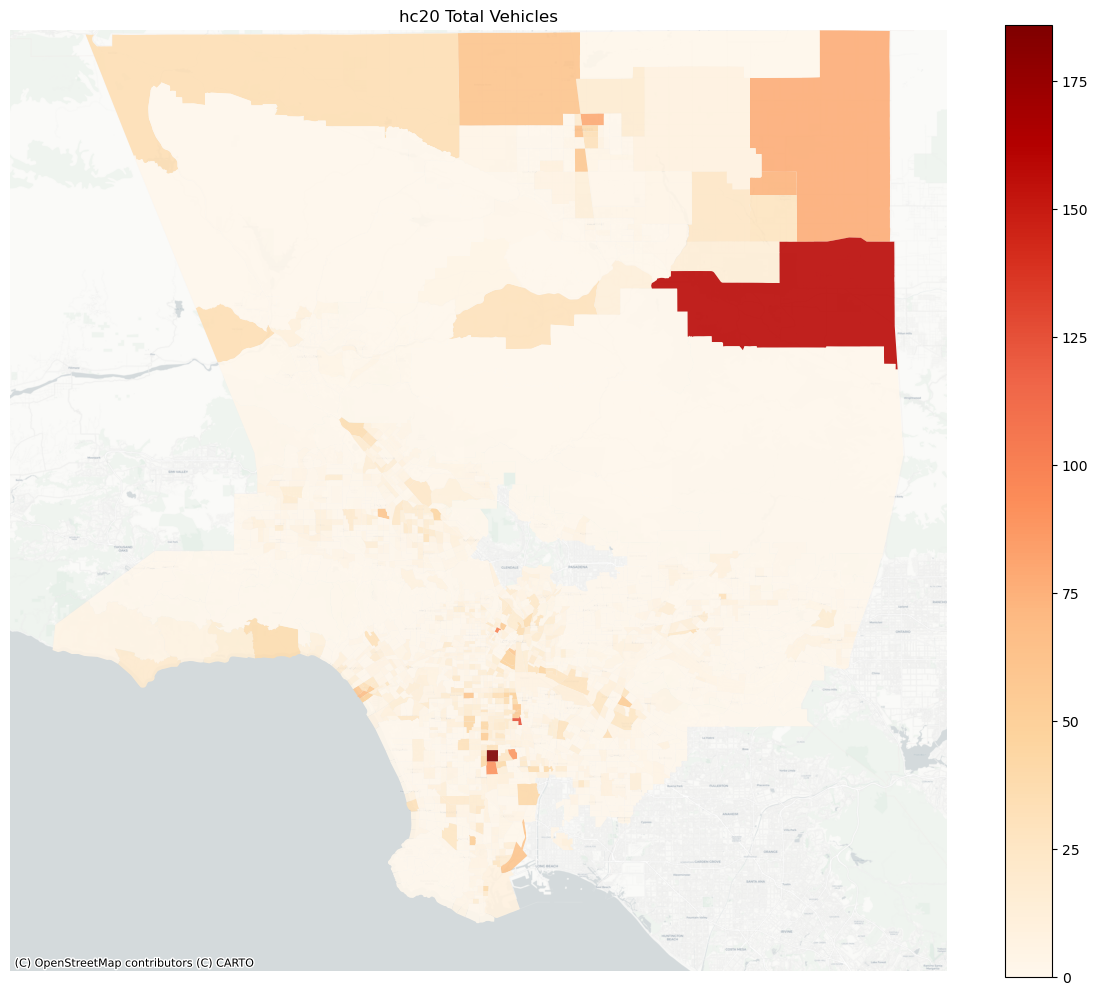

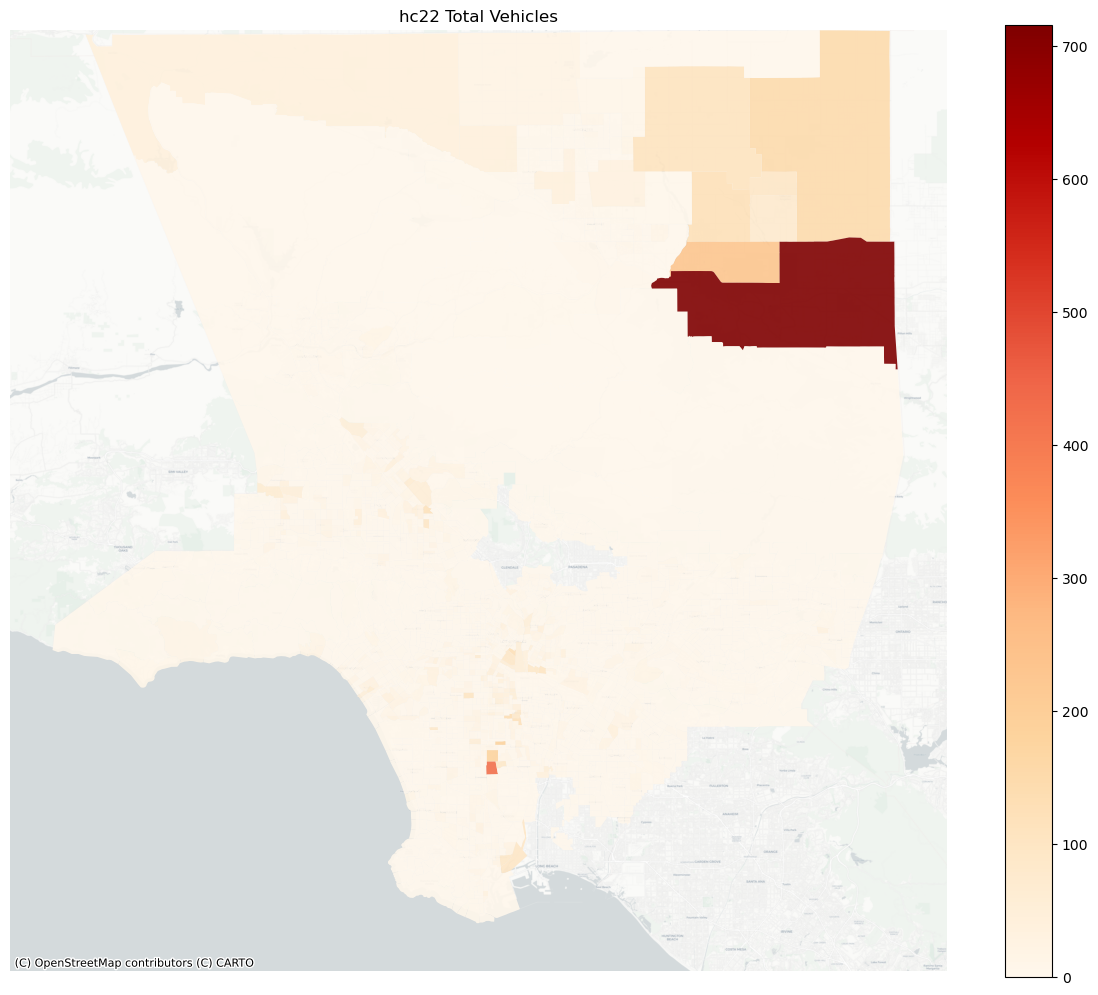

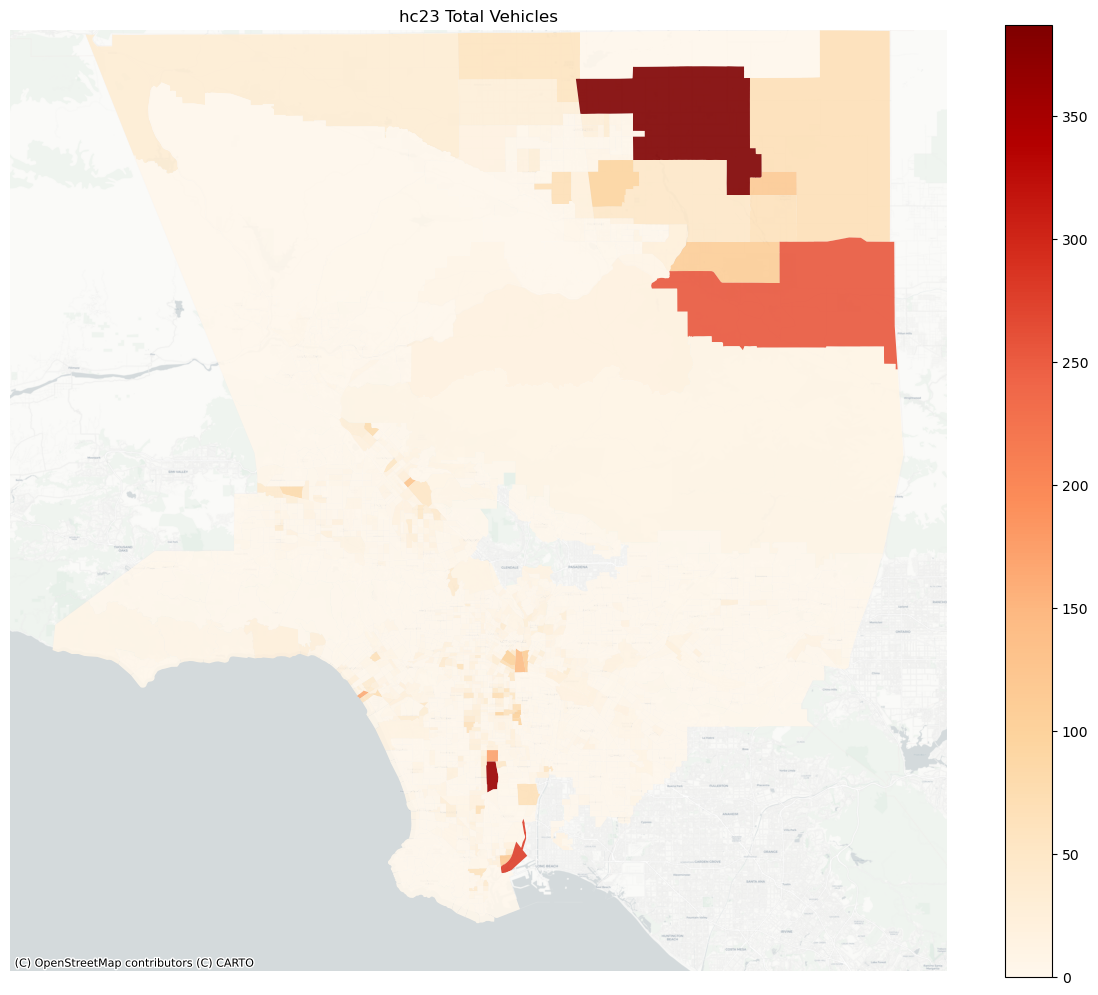

In [41]:
hc20.name = 'hc20'
hc22.name = 'hc22'
hc23.name = 'hc23'

# hc20, hc22（tracts19）
for df in [hc20, hc22]:
    df_merged = df.merge(tracts19[['GEOID', 'geometry']], on='GEOID', how='left')
    gdf = gpd.GeoDataFrame(df_merged, geometry='geometry', crs=tracts19.crs).to_crs(epsg=3857)

    fig, ax = plt.subplots(figsize=(12, 10))
    gdf.plot(column='total_vehicle', cmap='OrRd', legend=True, ax=ax, alpha=0.9)

    ax.set_ylim([3.98e6, 4.14e6])  # drop Catalina
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=12)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"{df.name} Total Vehicles")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# hc23（tracts23）
df_merged = hc23.merge(tracts23[['GEOID', 'geometry']], on='GEOID', how='left')
gdf = gpd.GeoDataFrame(df_merged, geometry='geometry', crs=tracts23.crs).to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 10))
gdf.plot(column='total_vehicle', cmap='OrRd', legend=True, ax=ax, alpha=0.9)

ax.set_ylim([3.98e6, 4.14e6])
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=12)

ax.set_xticks([])
ax.set_yticks([])
ax.set_title("hc23 Total Vehicles")
plt.axis("off")
plt.tight_layout()
plt.show()

### ACS data

We have deactivated a couple of variables because the number of variables we can extract is limited to under 50 while the number of variables we listed here is 53+3(state, county, tract) = 56.
We selected the variables that overlap.

##### Defining ACS variables

In [42]:
acs_vars = [
    "B25077_001E",  # Median home value
    "B25064_001E",  # Median gross rent
    "B25088_001E",  # Median monthly owner costs (with mortgage)

    # Renter cost burden
    "B25070_004E",  # Rent 30.0 to 34.9% of income
    "B25070_005E",  # Rent 35.0 to 39.9%
    "B25070_006E",  # Rent 40.0 to 49.9%
    "B25070_007E",  # Rent 50.0% or more
    "B25070_001E",  # Total renters (denominator)

    # Owner cost burden
    "B25091_005E",  # Owner costs 30.0 to 34.9%
    "B25091_006E",  # Owner costs 35.0 to 39.9%
    "B25091_007E",  # Owner costs 40.0 to 49.9%
    "B25091_008E",  # Owner costs 50.0% or more
    "B25091_001E",  # Total owners (denominator)

    # Labor force
    "B23025_005E",  # Unemployed
    "B23025_003E",  # Civilian labor force (denominator)

    # Poverty
    "B17001_002E",  # Population below poverty line
    "B17001_001E",  # Population for whom poverty status is determined

    "B19083_001E",  # Gini index of income inequality

    # Public assistance
    "B19057_002E",  # With public assistance income
    "B19057_001E",  # Total households

    # HUD housing
    "B25022_002E",  # Occupied HUD-assisted units
    "B25022_001E",  # Total HUD-assisted units

    # Age of housing
    "B25034_002E",  # Units built in 1939 or earlier
    "B25034_001E",  # Total housing units

    # Hispanic origin
    "B03003_003E",  # Hispanic or Latino population
    "B03003_001E",  # Total population

    # In-migration
    "B07001_017E",  # Movers from another U.S. county
    "B07001_001E",  # Total population 1 year and over

    # Household type
    "B11001_003E",  # One-person households
    "B11001_001E",  # Total households

    # Age: Seniors 65+ (Male)
    "B01001_020E", "B01001_021E", "B01001_022E", "B01001_023E", "B01001_024E", "B01001_025E",
    # Age: Seniors 65+ (Female)
    "B01001_044E", "B01001_045E", "B01001_046E", "B01001_047E", "B01001_048E", "B01001_049E",

    # Age: Children <18 (Male)
    "B01001_003E", "B01001_004E", "B01001_005E", "B01001_006E",
    # Age: Children <18 (Female)
    "B01001_027E", "B01001_028E", "B01001_029E", "B01001_030E",

    "B01001_001E",  # Total population (for age shares)

    # Overcrowding
    "B25014_003E",  # 1.01 to 1.50 persons per room
    "B25014_004E",  # 1.51+ persons per room
    "B25014_001E",  # Total housing units (for overcrowding rate)

    "B25001_001E"   # Total housing units (for density)
]

##### Obtaining ACS data from US census by using API and save them as CSV files

In [43]:
# key = 'e024759e68ac64e5f031a35c74016bdf988adce6'
# years = [2020, 2022, 2023]

# # Splitting the list of acs variables with 25
# acs_var_groups = [
#     acs_vars[i:i+25] for i in range(0, len(acs_vars), 25)
# ]

# # Designating the location of saving dataframe (CSV)
# output_dir = os.path.expanduser("~/Desktop/UP213_group/Data/ACS")
# os.makedirs(output_dir, exist_ok=True)

# for year in years:
#     df_full = None

#     for var_group in acs_var_groups:
#         var_string = ",".join(var_group)
#         url = f'https://api.census.gov/data/{year}/acs/acs5?get={var_string}&for=tract:*&in=state:06%20county:037&key={key}'
#         r = requests.get(url)

#         # handling errors
#         if r.status_code != 200:
#             print(f"Error fetching {year} data for: {var_string}")
#             print(r.text)
#             continue

#         data = r.json()
#         df = pd.DataFrame(data[1:], columns=data[0])
#         df['GEOID'] = '06037' + df['tract']
#         df = df.set_index('GEOID')
#         df = df.drop(columns=['state', 'county', 'tract'])

#         # converting data into float
#         df[var_group] = df[var_group].apply(pd.to_numeric, errors='coerce')

#         # merging data splitted with 25 variables
#         if df_full is None:
#             df_full = df
#         else:
#             df_full = df_full.join(df, how='outer')

#     # creating dataframe for each year
#     globals()[f"acs{str(year)[-2:]}"] = df_full

#     # saving as csv file
#     df_full.to_csv(os.path.join(output_dir, f"acs{str(year)[-2:]}.csv"))
#     print(f"Saved: acs{str(year)[-2:]}.csv")

##### non-used cells

In [44]:
# import requests
# import pandas as pd
# import numpy as np

# key = 'e024759e68ac64e5f031a35c74016bdf988adce6'
# years = [2020, 2022, 2023]
# acs_vars = [
#     "B25077_001E",  # Median home value
#     "B25064_001E",  # Median gross rent
#     "B25088_001E",  # Median monthly owner costs (with mortgage)

#     # Renter cost burden
#     "B25070_004E",  # Rent 30.0 to 34.9% of income
#     "B25070_005E",  # Rent 35.0 to 39.9%
#     "B25070_006E",  # Rent 40.0 to 49.9%
#     "B25070_007E",  # Rent 50.0% or more
#     "B25070_001E",  # Total renters (denominator)

#     # Owner cost burden
#     "B25091_005E",  # Owner costs 30.0 to 34.9%
#     "B25091_006E",  # Owner costs 35.0 to 39.9%
#     "B25091_007E",  # Owner costs 40.0 to 49.9%
#     "B25091_008E",  # Owner costs 50.0% or more
#     "B25091_001E",  # Total owners (denominator)

#     # Labor force
#     "B23025_005E",  # Unemployed
#     "B23025_003E",  # Civilian labor force (denominator)

#     # Poverty
#     "B17001_002E",  # Population below poverty line
#     "B17001_001E",  # Population for whom poverty status is determined

#     "B19083_001E",  # Gini index of income inequality

#     # Public assistance
#     "B19057_002E",  # With public assistance income
#     "B19057_001E",  # Total households

#     # HUD housing
#     "B25022_002E",  # Occupied HUD-assisted units
#     "B25022_001E",  # Total HUD-assisted units

#     # Age of housing
#     "B25034_002E",  # Units built in 1939 or earlier
#     "B25034_001E",  # Total housing units

#     # Hispanic origin
#     "B03003_003E",  # Hispanic or Latino population
#     "B03003_001E",  # Total population

#     # In-migration
#     "B07001_017E",  # Movers from another U.S. county
#     "B07001_001E",  # Total population 1 year and over

#     # Household type
#     "B11001_003E",  # One-person households
#     "B11001_001E",  # Total households

#     # Age: Seniors 65+ (Male)
#     "B01001_020E", "B01001_021E", "B01001_022E", "B01001_023E", "B01001_024E", "B01001_025E",
#     # Age: Seniors 65+ (Female)
#     "B01001_044E", "B01001_045E", "B01001_046E", "B01001_047E", "B01001_048E", "B01001_049E",

#     # Age: Children <18 (Male)
#     "B01001_003E", "B01001_004E", "B01001_005E", "B01001_006E",
#     # Age: Children <18 (Female)
#     "B01001_027E", "B01001_028E", "B01001_029E", "B01001_030E",

#     "B01001_001E",  # Total population (for age shares)

#     # Overcrowding
#     "B25014_003E",  # 1.01 to 1.50 persons per room
#     "B25014_004E",  # 1.51+ persons per room
#     "B25014_001E",  # Total housing units (for overcrowding rate)

#     "B25001_001E"   # Total housing units (for density)
# ]

# acs_var_string = ",".join(acs_vars)

# for year in years:
#     url = f'https://api.census.gov/data/{year}/acs/acs5?get={acs_var_string}&for=tract:*&in=state:06%20county:037&key={key}'
#     r = requests.get(url)

#     acsdata = r.json()
#     df = pd.DataFrame(acsdata[1:], columns=acsdata[0])
#     df['GEOID'] = '06037' + df['tract']
#     df = df.set_index('GEOID')
#     df[acs_vars] = df[acs_vars].astype(float)
#     globals()[f'acs{str(year)[-2:]}'] = df

In [45]:
# import requests
# import pandas as pd
# import numpy as np

# key = 'e024759e68ac64e5f031a35c74016bdf988adce6'
# years = [2020, 2022, 2023]

# # ACS variables to request
# # For documentation on variables selection, see page 21, https://www.huduser.gov/portal/sites/default/files/pdf/market-predictors-of-homelessness.pdf
# acs_vars = [
#     "B25077_001E",  # Median home value
#     "B25064_001E",  # Median gross rent
#     "B25088_001E",  # Median monthly owner costs (with mortgage)

#     # Renter cost burden
#     "B25070_004E",  # Rent 30.0 to 34.9% of income
#     "B25070_005E",  # Rent 35.0 to 39.9%
#     "B25070_006E",  # Rent 40.0 to 49.9%
#     "B25070_007E",  # Rent 50.0% or more
#     "B25070_001E",  # Total renters (denominator)

#     # Owner cost burden
#     "B25091_005E",  # Owner costs 30.0 to 34.9%
#     "B25091_006E",  # Owner costs 35.0 to 39.9%
#     "B25091_007E",  # Owner costs 40.0 to 49.9%
#     "B25091_008E",  # Owner costs 50.0% or more
#     "B25091_001E",  # Total owners (denominator)

#     # Labor force
#     "B23025_005E",  # Unemployed
#     "B23025_003E",  # Civilian labor force (denominator)

#     # Poverty
#     "B17001_002E",  # Population below poverty line
#     "B17001_001E",  # Population for whom poverty status is determined

#     "B19083_001E",  # Gini index of income inequality

#     # Public assistance
#     "B19057_002E",  # With public assistance income
#     "B19057_001E",  # Total households

#     # HUD housing
#     "B25022_002E",  # Occupied HUD-assisted units
#     "B25022_001E",  # Total HUD-assisted units

#     # Age of housing
#     "B25034_002E",  # Units built in 1939 or earlier
#     "B25034_001E",  # Total housing units

#     # Hispanic origin
#     "B03003_003E",  # Hispanic or Latino population
#     "B03003_001E",  # Total population

#     # In-migration
#     "B07001_017E",  # Movers from another U.S. county
#     "B07001_001E",  # Total population 1 year and over

#     # Household type
#     "B11001_003E",  # One-person households
#     "B11001_001E",  # Total households

#     # Age: Seniors 65+ (Male)
#     "B01001_020E", "B01001_021E", "B01001_022E", "B01001_023E", "B01001_024E", "B01001_025E",
#     # Age: Seniors 65+ (Female)
#     "B01001_044E", "B01001_045E", "B01001_046E", "B01001_047E", "B01001_048E", "B01001_049E",

#     # Age: Children <18 (Male)
#     "B01001_003E", "B01001_004E", "B01001_005E", "B01001_006E",
#     # Age: Children <18 (Female)
#     "B01001_027E", "B01001_028E", "B01001_029E", "B01001_030E",

#     "B01001_001E",  # Total population (for age shares)

#     # Overcrowding
#     "B25014_003E",  # 1.01 to 1.50 persons per room
#     "B25014_004E",  # 1.51+ persons per room
#     "B25014_001E",  # Total housing units (for overcrowding rate)

#     "B25001_001E"   # Total housing units (for density)
# ]

# # Dictionary to store dataframes by year
# acs_data_by_year = {}

# for year in years:
#     print(f"Downloading ACS {year} data...")

#     var_string = ",".join(acs_vars)
#     url = f'https://api.census.gov/data/{year}/acs/acs5?get={var_string}&for=tract:*&in=state:06 county:037&key={key}'

#     r = requests.get(url)
#     if r.status_code != 200:
#         print(f"Failed to fetch data for {year}: {r.status_code}")
#         continue

#     data = r.json()
#     df = pd.DataFrame(data[1:], columns=data[0])

#     # Make GEOID
#     df['GEOID'] = '06037' + df['tract']
#     df.set_index('GEOID', inplace=True)
#     df.drop(columns=['state', 'county', 'tract'], inplace=True)

#     # Convert all columns to numeric (coerce errors to NaN)
#     for col in df.columns:
#         df[col] = pd.to_numeric(df[col], errors='coerce')

#     # Store cleaned dataframe
#     acs_data_by_year[year] = df


In [46]:
#import requests
#import json
#import numpy as np

#key = 'e024759e68ac64e5f031a35c74016bdf988adce6'
#years = [2020, 2022, 2023]
#acs_vars = [
#     "B25077_001E",  # Median home value
#     "B25064_001E",  # Median gross rent
#     "B25088_001E",  # Median selected monthly owner costs (with mortgage)
#     "B25070_004E",  # Rent 30.0 to 34.9% of household income
#     "B25070_005E",  # Rent 35.0 to 39.9%
#     "B25070_006E",  # Rent 40.0 to 49.9%
#     "B25070_007E",  # Rent 50.0% or more
#     "B25070_001E",  # Total renters (denominator)
#     "B25091_005E",  # Owner cost 30.0 to 34.9% of household income
#     "B25091_006E",  # Owner cost 35.0 to 39.9%
#     "B25091_007E",  # Owner cost 40.0 to 49.9%
#     "B25091_008E",  # Owner cost 50.0% or more
#     "B25091_001E",  # Total owners (denominator)
#     "B23025_005E",  # Unemployed
#     "B23025_003E",  # Civilian labor force (denominator)
#     "B17001_002E",  # Income below poverty level
#     "B17001_001E",  # Total population for poverty status
#     "B19083_001E",  # Gini index of income inequality
#     "B19057_002E",  # With public assistance income
#     "B19057_001E",  # Total households
#     "B25022_002E",  # HUD-subsidized units occupied
#     "B25022_001E",  # Total HUD-subsidized units
#     "B25034_002E",  # Housing units built in 1939 or earlier
#     "B25034_001E",  # Total housing units (for % pre-1940)
#     "B03003_003E",  # Hispanic or Latino population
#     "B03003_001E",  # Total population (for % Hispanic)
#     "B07001_017E",  # Movers from different U.S. county
#     "B07001_001E",  # Population 1 year and over
#     "B11001_003E",  # One-person households
#     "B11001_001E",  # Total households
#     "B01001_020E", "B01001_021E", "B01001_022E", "B01001_023E", "B01001_024E", "B01001_025E",  # Male 65+
#     "B01001_044E", "B01001_045E", "B01001_046E", "B01001_047E", "B01001_048E", "B01001_049E",  # Female 65+
#     "B01001_003E", "B01001_004E", "B01001_005E", "B01001_006E",  # Male under 18
#     "B01001_027E", "B01001_028E", "B01001_029E", "B01001_030E",  # Female under 18
#     "B01001_001E",  # Total population (for age shares)
#     "B25014_003E",  # Occupants per room: 1.01 to 1.50
#     "B25014_004E",  # Occupants per room: 1.51 or more
#     "B25014_001E",  # Total housing units (for overcrowding)
#     "B25001_001E"   # Total housing units (for density)
# ]

#acs_var_string = ",".join(acs_vars)

#for year in years:
#     url = f'https://api.census.gov/data/{year}/acs/acs5?get={acs_vars}&for=tract:*&in=state:06%20county:037&key={key}'
#     r = requests.get(url)
#     acsdata = r.json()
#     df = pd.DataFrame(acsdata[1:], columns=acsdata[0])

     #making GEOID column
#     df['GEOID'] = '06037' + df['tract']

     #setting GEOID as the index
#     df = df.set_index('GEOID')

     #changing the data type of columns into int
#     cols_to_convert = ['B25003_001E', 'B25003_002E', 'B25003_003E', 'B19013_001E']
#     df[acs_vars] = df[acs_vars].astype(float)

     #making usable variables by calculation
#     df['pct_renter'] = df['B25003_003E'] / df['B25003_001E'] * 100

#     #renaming the columns
#     df.rename(columns={'B19013_001E': 'median_hh_income'}, inplace=True)
    
#     # replacing -666666666 in "median_hh_income" into NaN
#     df["median_hh_income"] = df["median_hh_income"].replace(-666666666, np.nan)
    
     #making dataframes named acs20, acs22, acs23
#     globals()[f'acs{str(year)[-2:]}'] = df

now we have ACS data named (acs20, acs22, acs23)

##### loading saved ACS data (csv)

In [47]:
base_path = os.path.expanduser("~/Desktop/UP213_group/Data/ACS")

acs20 = pd.read_csv(os.path.join(base_path, "acs20.csv"), dtype={"GEOID": str}, index_col="GEOID")
acs22 = pd.read_csv(os.path.join(base_path, "acs22.csv"), dtype={"GEOID": str}, index_col="GEOID")
acs23 = pd.read_csv(os.path.join(base_path, "acs23.csv"), dtype={"GEOID": str}, index_col="GEOID")

##### calculating the area of each tract for calculating the housing density

In [48]:
tracts23 = tracts23.to_crs(epsg=3497)
tracts23["area_km2"] = tracts23.geometry.area / 1e6  # m² → km²

In [49]:
tracts23 = tracts23.set_index('GEOID')

#### Arranging and renaming variables

In [50]:
def process_acs(df, tracts23):
    # Rename selected columns
    df = df.rename(columns={
        "B25077_001E": "median_home_value",
        "B25064_001E": "median_gross_rent",
        "B25088_001E": "median_owner_costs_mortgage",
        "B19083_001E": "gini",
        "B25001_001E": "n_total_units"
    })

    # Renter cost burden
    for col in ["B25070_004E", "B25070_005E", "B25070_006E", "B25070_007E"]:
        df[col.replace("E", "_pct")] = df[col] / df["B25070_001E"] * 100
    df = df.rename(columns={
        "B25070_004_pct": "pct_rent_30_34",
        "B25070_005_pct": "pct_rent_35_39",
        "B25070_006_pct": "pct_rent_40_49",
        "B25070_007_pct": "pct_rent_50plus"
    })

    # Owner cost burden
    for col in ["B25091_005E", "B25091_006E", "B25091_007E", "B25091_008E"]:
        df[col.replace("E", "_pct")] = np.where(
            df["B25091_001E"] > 0,
            df[col] / df["B25091_001E"] * 100,
            np.nan
        )
    df = df.rename(columns={
        "B25091_005_pct": "pct_owner_cost_30_34",
        "B25091_006_pct": "pct_owner_cost_35_39",
        "B25091_007_pct": "pct_owner_cost_40_49",
        "B25091_008_pct": "pct_owner_cost_50plus"
    })

    # Labor force
    df["unemployment_rate"] = np.where(
        df["B23025_003E"] > 0,
        df["B23025_005E"] / df["B23025_003E"] * 100,
        np.nan
    )

    # Poverty
    df["poverty_rate"] = np.where(
        df["B17001_001E"] > 0,
        df["B17001_002E"] / df["B17001_001E"] * 100,
        np.nan
    )

    # Public assistance
    df["public_assistance_rate"] = np.where(
        df["B19057_001E"] > 0,
        df["B19057_002E"] / df["B19057_001E"] * 100,
        np.nan
    )

    # HUD housing
    df["hud_rate"] = np.where(
        df["B25022_001E"] > 0,
        df["B25022_002E"] / df["B25022_001E"] * 100,
        np.nan
    )

    # Age of housing
    df["oldhouses_rate"] = np.where(
        df["B25034_001E"] > 0,
        df["B25034_002E"] / df["B25034_001E"] * 100,
        np.nan
    )

    # Hispanic origin
    df["hispanic_rate"] = np.where(
        df["B03003_001E"] > 0,
        df["B03003_003E"] / df["B03003_001E"] * 100,
        np.nan
    )

    # In-migration
    df["imigration_rate"] = np.where(
        df["B07001_001E"] > 0,
        df["B07001_017E"] / df["B07001_001E"] * 100,
        np.nan
    )

    # Household type
    df["1phouseholds_rate"] = np.where(
        df["B11001_001E"] > 0,
        df["B11001_003E"] / df["B11001_001E"] * 100,
        np.nan
    )

    # Older/Younger generation
    df["n_age_65plus"] = df[[
        "B01001_020E", "B01001_021E", "B01001_022E",
        "B01001_023E", "B01001_024E", "B01001_025E",
        "B01001_044E", "B01001_045E", "B01001_046E",
        "B01001_047E", "B01001_048E", "B01001_049E"
    ]].astype(float).sum(axis=1)

    df["n_age_under18"] = df[[
        "B01001_003E", "B01001_004E", "B01001_005E", "B01001_006E",
        "B01001_027E", "B01001_028E", "B01001_029E", "B01001_030E"
    ]].astype(float).sum(axis=1)

    df["over65_rate"] = np.where(
        df["B01001_001E"] > 0,
        df["n_age_65plus"] / df["B01001_001E"] * 100,
        np.nan
    )

    df["under18_rate"] = np.where(
        df["B01001_001E"] > 0,
        df["n_age_under18"] / df["B01001_001E"] * 100,
        np.nan
    )

    # Overcrowding
    df["n_overcrowded_units"] = df[[
        "B25014_003E", "B25014_004E"
    ]].astype(float).sum(axis=1)

    df["overcrowded_rate"] = np.where(
        df["B25014_001E"] > 0,
        df["n_overcrowded_units"] / df["B25014_001E"] * 100,
        np.nan
    )

    # Housing density
    df = df.join(tracts23[["area_km2"]], how="left")
    df["housing_density"] = np.where(
        df["area_km2"] > 0,
        df["n_total_units"] / df["area_km2"],
        np.nan
    )

    # adding geometry of tracts23
    df = df.join(tracts23[["geometry"]], how="left")
    df = gpd.GeoDataFrame(df, geometry="geometry", crs=tracts23.crs)
    df = df.to_crs(epsg=4326)
    
    return df

In [51]:
acs20 = process_acs(acs20, tracts23)
acs22 = process_acs(acs22, tracts23)
acs23 = process_acs(acs23, tracts23)

In [52]:
tracts23 = tracts23.to_crs(epsg=4326)

In [53]:
acs20

,median_home_value,median_gross_rent,median_owner_costs_mortgage,B25070_004E,B25070_005E,B25070_006E,B25070_007E,B25070_001E,B25091_005E,B25091_006E,...,1phouseholds_rate,n_age_65plus,n_age_under18,over65_rate,under18_rate,n_overcrowded_units,overcrowded_rate,area_km2,housing_density,geometry
GEOID,,,,,,,,,,,,,,,,,,,,,
06037101110,502200,1723,2217,57,117,34,59,627,81,40,...,48.571429,702.0,738.0,17.894469,18.812134,878.0,58.338870,1.142307,1426.062080,"POLYGON ((-118.3023 34.2587, -118.30092 34.258..."
06037101122,658800,2256,2373,0,47,0,52,336,94,75,...,57.718121,877.0,606.0,21.291576,14.712309,995.0,74.198359,2.643819,531.806521,"POLYGON ((-118.30335 34.27371, -118.30331 34.2..."
06037101220,550800,1291,2060,47,58,155,95,819,77,126,...,47.132867,536.0,740.0,14.198675,19.602649,555.0,38.811189,0.698830,2092.068739,"POLYGON ((-118.28593 34.25405, -118.28593 34.2..."
06037101221,461600,1416,1833,82,65,127,95,1205,52,18,...,50.495704,572.0,676.0,15.104304,17.850541,299.0,19.762062,0.354148,4424.698760,"POLYGON ((-118.29792 34.25597, -118.29697 34.2..."
06037101222,378400,1330,1732,107,9,37,0,859,0,38,...,46.955624,406.0,550.0,14.942952,20.242915,110.0,11.351909,0.296490,3325.576791,"POLYGON ((-118.29434 34.25234, -118.29318 34.2..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
06037980038,-666666666,-666666666,-666666666,0,0,0,0,0,0,0,...,NaN,0.0,0.0,NaN,NaN,0.0,NaN,4.516716,0.000000,"POLYGON ((-118.39099 34.00167, -118.39094 34.0..."
06037980039,-666666666,-666666666,-666666666,0,0,0,0,0,0,0,...,NaN,0.0,0.0,NaN,NaN,0.0,NaN,1.360255,0.000000,"POLYGON ((-118.36216 34.13903, -118.36121 34.1..."
06037990100,-666666666,-666666666,-666666666,0,0,0,0,0,0,0,...,NaN,0.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,None


#### data cleaning

In [54]:
import numpy as np

acs20 = acs20.applymap(lambda x: np.nan if isinstance(x, (int, float)) and x < 0 else x)
acs22 = acs22.applymap(lambda x: np.nan if isinstance(x, (int, float)) and x < 0 else x)
acs23 = acs23.applymap(lambda x: np.nan if isinstance(x, (int, float)) and x < 0 else x)

/var/folders/lx/_3z8wwyx3ds15_0k28hby_h80000gn/T/ipykernel_4839/2317457581.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  acs20 = acs20.applymap(lambda x: np.nan if isinstance(x, (int, float)) and x < 0 else x)
/var/folders/lx/_3z8wwyx3ds15_0k28hby_h80000gn/T/ipykernel_4839/2317457581.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  acs22 = acs22.applymap(lambda x: np.nan if isinstance(x, (int, float)) and x < 0 else x)
/var/folders/lx/_3z8wwyx3ds15_0k28hby_h80000gn/T/ipykernel_4839/2317457581.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  acs23 = acs23.applymap(lambda x: np.nan if isinstance(x, (int, float)) and x < 0 else x)


### checking the match rate

##### Tiger/Line and ACS

In [55]:
# #getting index as set
# index_tracts = set(tracts20.index)
# index_acs = set(acs20.index)

# #counting the shared GEOIDs
# common_geoids = index_tracts & index_acs
# num_common = len(common_geoids)

# #counting the GEOID of each dataframe
# num_tracts = len(index_tracts)
# num_acs = len(index_acs)

# #calculating the matching ratio
# match_rate_tracts = num_common / num_tracts
# match_rate_acs = num_common / num_acs
# print(match_rate_tracts)
# print(match_rate_acs)

100% matching rate between ACS and Tiger/Lines after 2020

##### Tiger/Line and LAHSA

In [56]:
# #getting index as set
# index_tracts = set(tracts20.index)
# index_hc = set(hc23.index)

# #counting the shared GEOIDs
# common_geoids = index_tracts & index_hc
# num_common = len(common_geoids)

# #counting the GEOID of each dataframe
# num_tracts = len(index_tracts)
# num_hc = len(index_hc)

# #calculating the matching ratio
# match_rate_tracts = num_common / num_tracts
# match_rate_hc = num_common / num_hc
# print(match_rate_tracts)
# print(match_rate_hc)

- LAHSA has applied the 2020 census tract code after 2023 and use 2010 census tract code in 2020 and 2022. (85% out LAHSA tracts matched and 75% of census tracts matched)
- Even 2023, matching rate is 93% (LAHSA data does not include all census tracts)

##### ACS and LAHSA

In [57]:
# #getting index as set
# index_hc = set(hc22.index)
# index_acs = set(acs20.index)

# #counting the shared GEOIDs
# common_index = index_hc & index_acs
# num_common = len(common_index)

# #counting the GEOID of each dataframe
# num_hc = len(index_hc)
# num_acs = len(index_acs)

# #calculating the matching ratio
# match_rate_hc = num_common / num_hc
# match_rate_acs = num_common / num_acs
# print(match_rate_hc)
# print(match_rate_acs)

same with the result of the section above

### joining data

##### ACS and LAHSA of each year

In [58]:
merged20 = acs20.join(hc20, how='left', rsuffix='_hc')
merged22 = acs22.join(hc22, how='left', rsuffix='_hc')
merged23 = acs23.join(hc23, how='left', rsuffix='_hc')

##### adding the column indicating the year of the data

In [59]:
merged20["year"] = 2020
merged22["year"] = 2022
merged23["year"] = 2023

##### resetting the index (changing GEOID into normal column)

In [60]:
merged20 = merged20.reset_index()
merged22 = merged22.reset_index()
merged23 = merged23.reset_index()

##### merging data of different years

In [61]:
merged_all = pd.concat([merged20, merged22, merged23], axis=0).reset_index(drop=True)

##### merging amenity data by using GEOID column

In [62]:
tracts23 = tracts23.reset_index()

cols_to_merge = ['GEOID',
                 'n_ArtsRecreation',
                 'n_Education',
                 'n_Hospitals',
                 'n_MunicipalServices',
                 'n_PhysicalFeatures',
                 'n_PublicSafety',
                 'n_Transportation',
                 'n_Pantry',
                 'n_Parking',]
tract_counts = tracts23[cols_to_merge].copy()
merged_all = merged_all.merge(tract_counts, on="GEOID", how="left")

#### creating location variables of each tract by taking the centroid 

In [63]:
merged_all = merged_all.to_crs(epsg=3497)
centroids = merged_all.geometry.centroid

merged_all["lon"] = centroids.x
merged_all["lat"] = centroids.y

#### exporting the geodataframe as gpkg file

In [64]:
merged_all.to_file("../Data/merged_all.gpkg", layer="merged_all", driver="GPKG")

In [65]:
merged_all.to_csv("../Data/merged_all.csv", index=False)

### Machine Learning

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# your code here
# I'm just going to throw in all of the columns
xvars = ['year',
         'n_ArtsRecreation',
         'n_Education',
         'n_Hospitals',
         'n_MunicipalServices',
         'n_PhysicalFeatures',
         'n_PublicSafety',
         'n_Transportation',
         'n_Pantry',
         'n_Parking',
         'non_vehicle_unsheltered',
#         'lon',
#         'lat'
]

acs_vars = [
    "median_home_value", "median_gross_rent", "median_owner_costs_mortgage", "gini", 
    "pct_rent_30_34", "pct_rent_35_39", "pct_rent_40_49", "pct_rent_50plus",
    "pct_owner_cost_30_34", "pct_owner_cost_35_39", "pct_owner_cost_40_49", "pct_owner_cost_50plus",
    "unemployment_rate", "poverty_rate", "public_assistance_rate", "hud_rate", "oldhouses_rate",
    "hispanic_rate", "imigration_rate", "1phouseholds_rate",
    "over65_rate", "under18_rate",
    "overcrowded_rate", "housing_density"
]

# Combine both lists
xvars = xvars + acs_vars

yvar = 'total_vehicle'

# create a dataframe with no NaNs
df_to_fit = merged_all[xvars+[yvar]].dropna()

In [67]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    df_to_fit[xvars], df_to_fit[yvar], test_size = 0.25, random_state = 1)
print(len(X_train), len(y_train) )
print(len(X_test), len(y_test) )

4047 4047
1349 1349


In [68]:
# initialize the random forest classifer object
rf = RandomForestRegressor(n_estimators = 50, random_state = 1)

# now fit the model
rf.fit(X_train, y_train)

# make predictions
y_pred = rf.predict(X_test)
y_pred

array([7.54, 2.74, 2.32, ..., 2.06, 5.48, 7.9 ])

In [69]:
print('Predicted fraction True: {:.4f}. Actual fraction True: {:.4f}'.format(
    y_pred.mean(), y_test.mean()))

Predicted fraction True: 6.3162. Actual fraction True: 5.6108


5.788895478131949


Text(0, 0.5, 'Predicted homelessness vehicle')

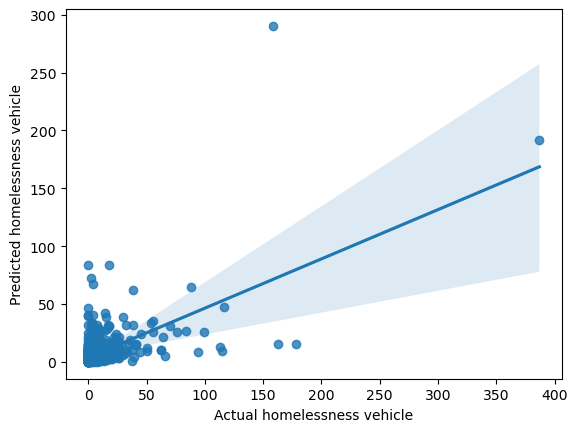

In [70]:
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt

# I used mean absolute error
print(metrics.mean_absolute_error(y_test, y_pred))

# but the scatter plot is more helpful to me
fig, ax = plt.subplots()
sns.regplot(x=y_test, y=y_pred, ax=ax)
ax.set_xlabel('Actual homelessness vehicle')
ax.set_ylabel('Predicted homelessness vehicle')

### Feature importances

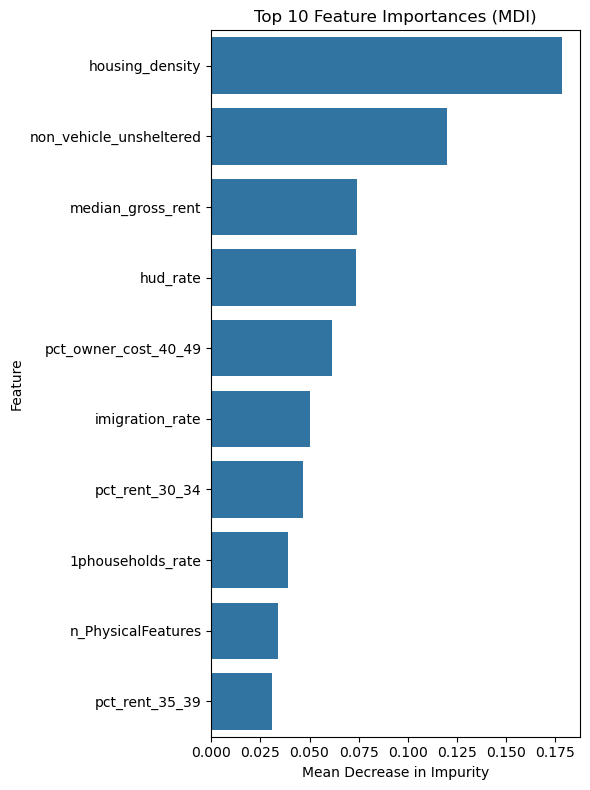

In [71]:
import numpy as np
import seaborn as sns

importances = rf.feature_importances_

# convert to a series, and give the index labels from our X_train dataframe
forest_importances = pd.Series(importances, index=X_train.columns)

# get the standard deviations to be able to plot the error bars
# acutally, these are no longer supported (for now) in seaborn, so we won't plot them
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

# sort the importances in descending order

forest_importances.sort_values(ascending=False, inplace=True)

# plot just the top 10
fig, ax = plt.subplots(figsize=(6, 8))
sns.barplot(x=forest_importances.values[:10], y=forest_importances.index[:10], ax=ax)
ax.set_title("Top 10 Feature Importances (MDI)")
ax.set_xlabel("Mean Decrease in Impurity")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

### Partial dependence plots

In [72]:
forest_importances

housing_density                0.178724
non_vehicle_unsheltered        0.120127
median_gross_rent              0.074233
hud_rate                       0.073702
pct_owner_cost_40_49           0.061284
imigration_rate                0.050360
pct_rent_30_34                 0.046748
1phouseholds_rate              0.039243
n_PhysicalFeatures             0.033819
pct_rent_35_39                 0.030826
hispanic_rate                  0.024288
median_home_value              0.022625
overcrowded_rate               0.019508
median_owner_costs_mortgage    0.019198
n_Education                    0.019014
pct_rent_50plus                0.017726
n_ArtsRecreation               0.015988
poverty_rate                   0.014439
unemployment_rate              0.013904
pct_owner_cost_30_34           0.012452
under18_rate                   0.011339
pct_rent_40_49                 0.011175
n_Transportation               0.010380
n_PublicSafety                 0.009475
public_assistance_rate         0.008999


In [73]:
forest_importances.index[:10]

Index(['housing_density', 'non_vehicle_unsheltered', 'median_gross_rent',
       'hud_rate', 'pct_owner_cost_40_49', 'imigration_rate', 'pct_rent_30_34',
       '1phouseholds_rate', 'n_PhysicalFeatures', 'pct_rent_35_39'],
      dtype='object')

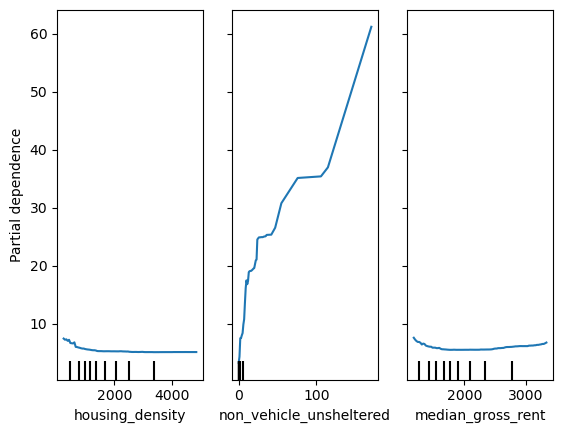

In [74]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(rf, X_test,
                                       forest_importances.index[:3])

#### Pairplots

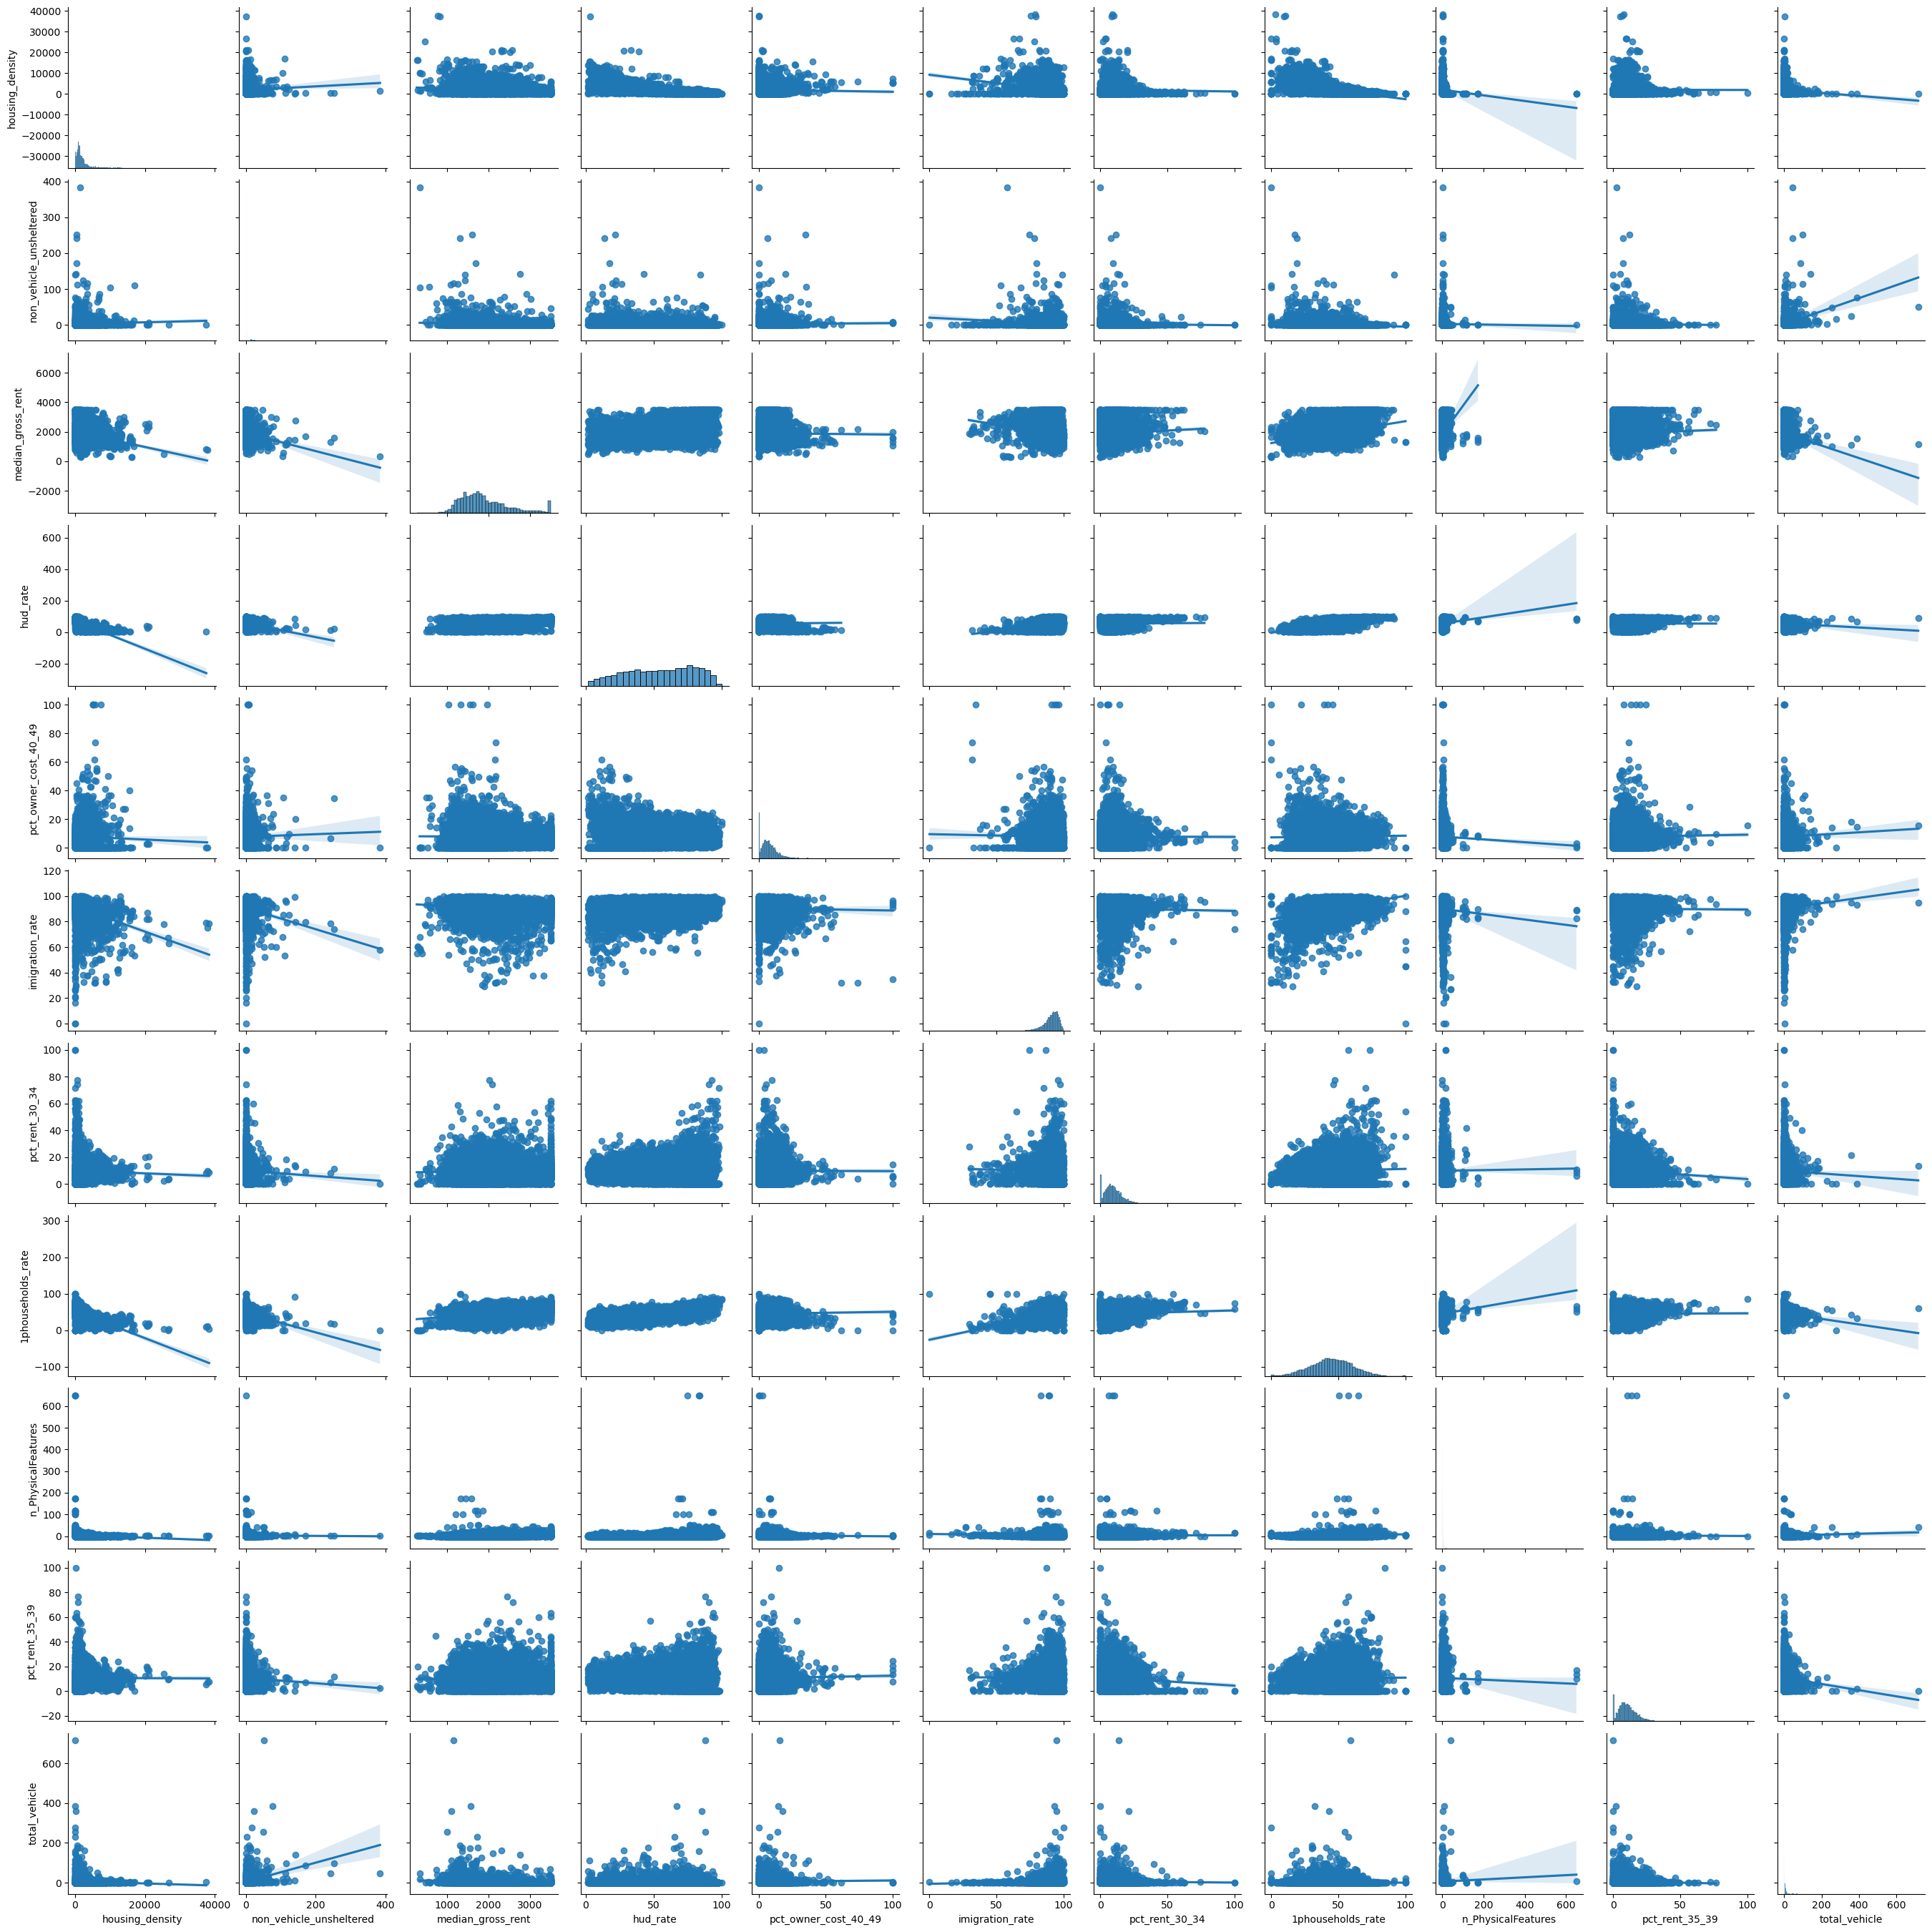

In [75]:
import seaborn as sns
cols_to_plot = list(forest_importances.index[:10])

if 'total_vehicle' not in cols_to_plot:
    cols_to_plot.append('total_vehicle')

ax = sns.pairplot(merged_all[cols_to_plot], kind='reg')

#### Standardization

In [76]:
from sklearn import preprocessing
scaler = preprocessing.StandardScaler().fit(merged_all[cols_to_plot])

In [77]:
merged_all_scaled = pd.DataFrame(scaler.transform(merged_all[cols_to_plot]), 
                         columns=cols_to_plot, index=merged_all.index)

#### Pairplots with standardized data

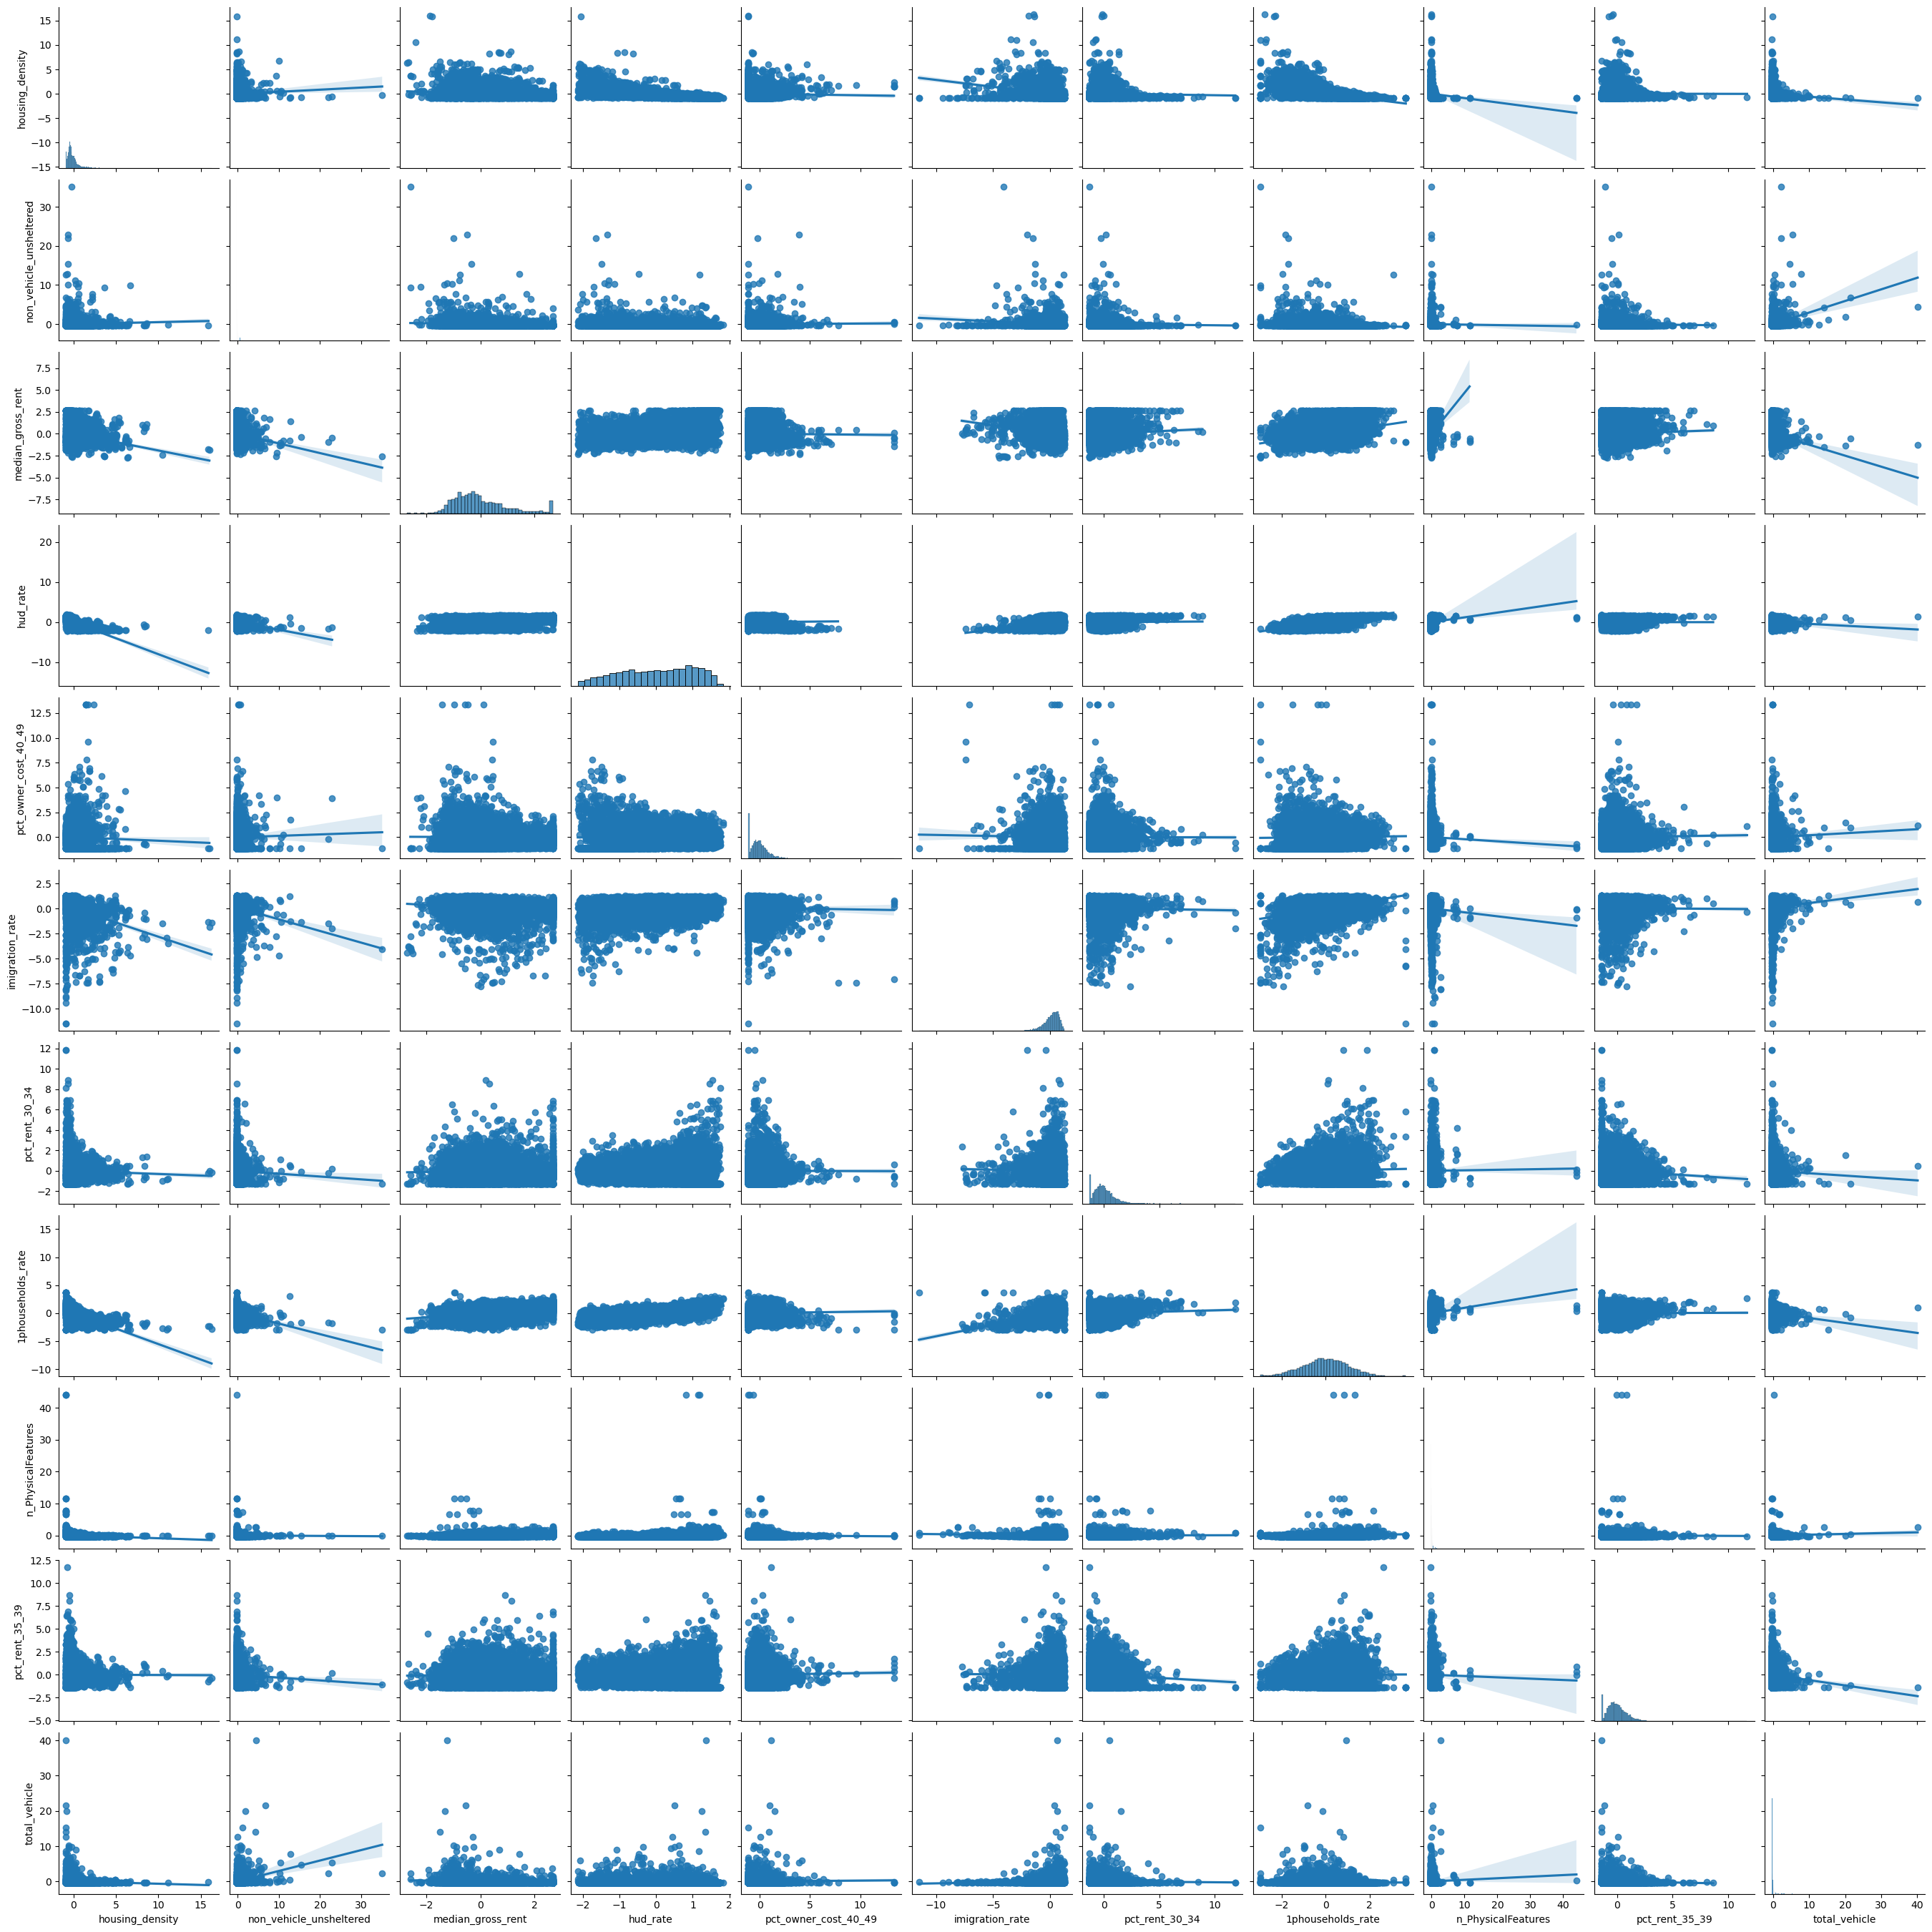

In [78]:
ax = sns.pairplot(merged_all_scaled, kind='reg')

### Cluster Analysis

In [80]:
merged_all_scaled['cluster_id'] = kmeans.labels_

/var/folders/lx/_3z8wwyx3ds15_0k28hby_h80000gn/T/ipykernel_4839/1920520206.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_all_scaled['cluster_id'] = kmeans.labels_


In [79]:
from sklearn.cluster import KMeans
merged_all_scaled = merged_all_scaled.dropna()
kmeans = KMeans(n_clusters=5, random_state=0).fit(merged_all_scaled)

In [81]:
merged_all_scaled.groupby('cluster_id').size()

cluster_id
0    1199
1    1091
2     869
3      64
4    2459
dtype: int64

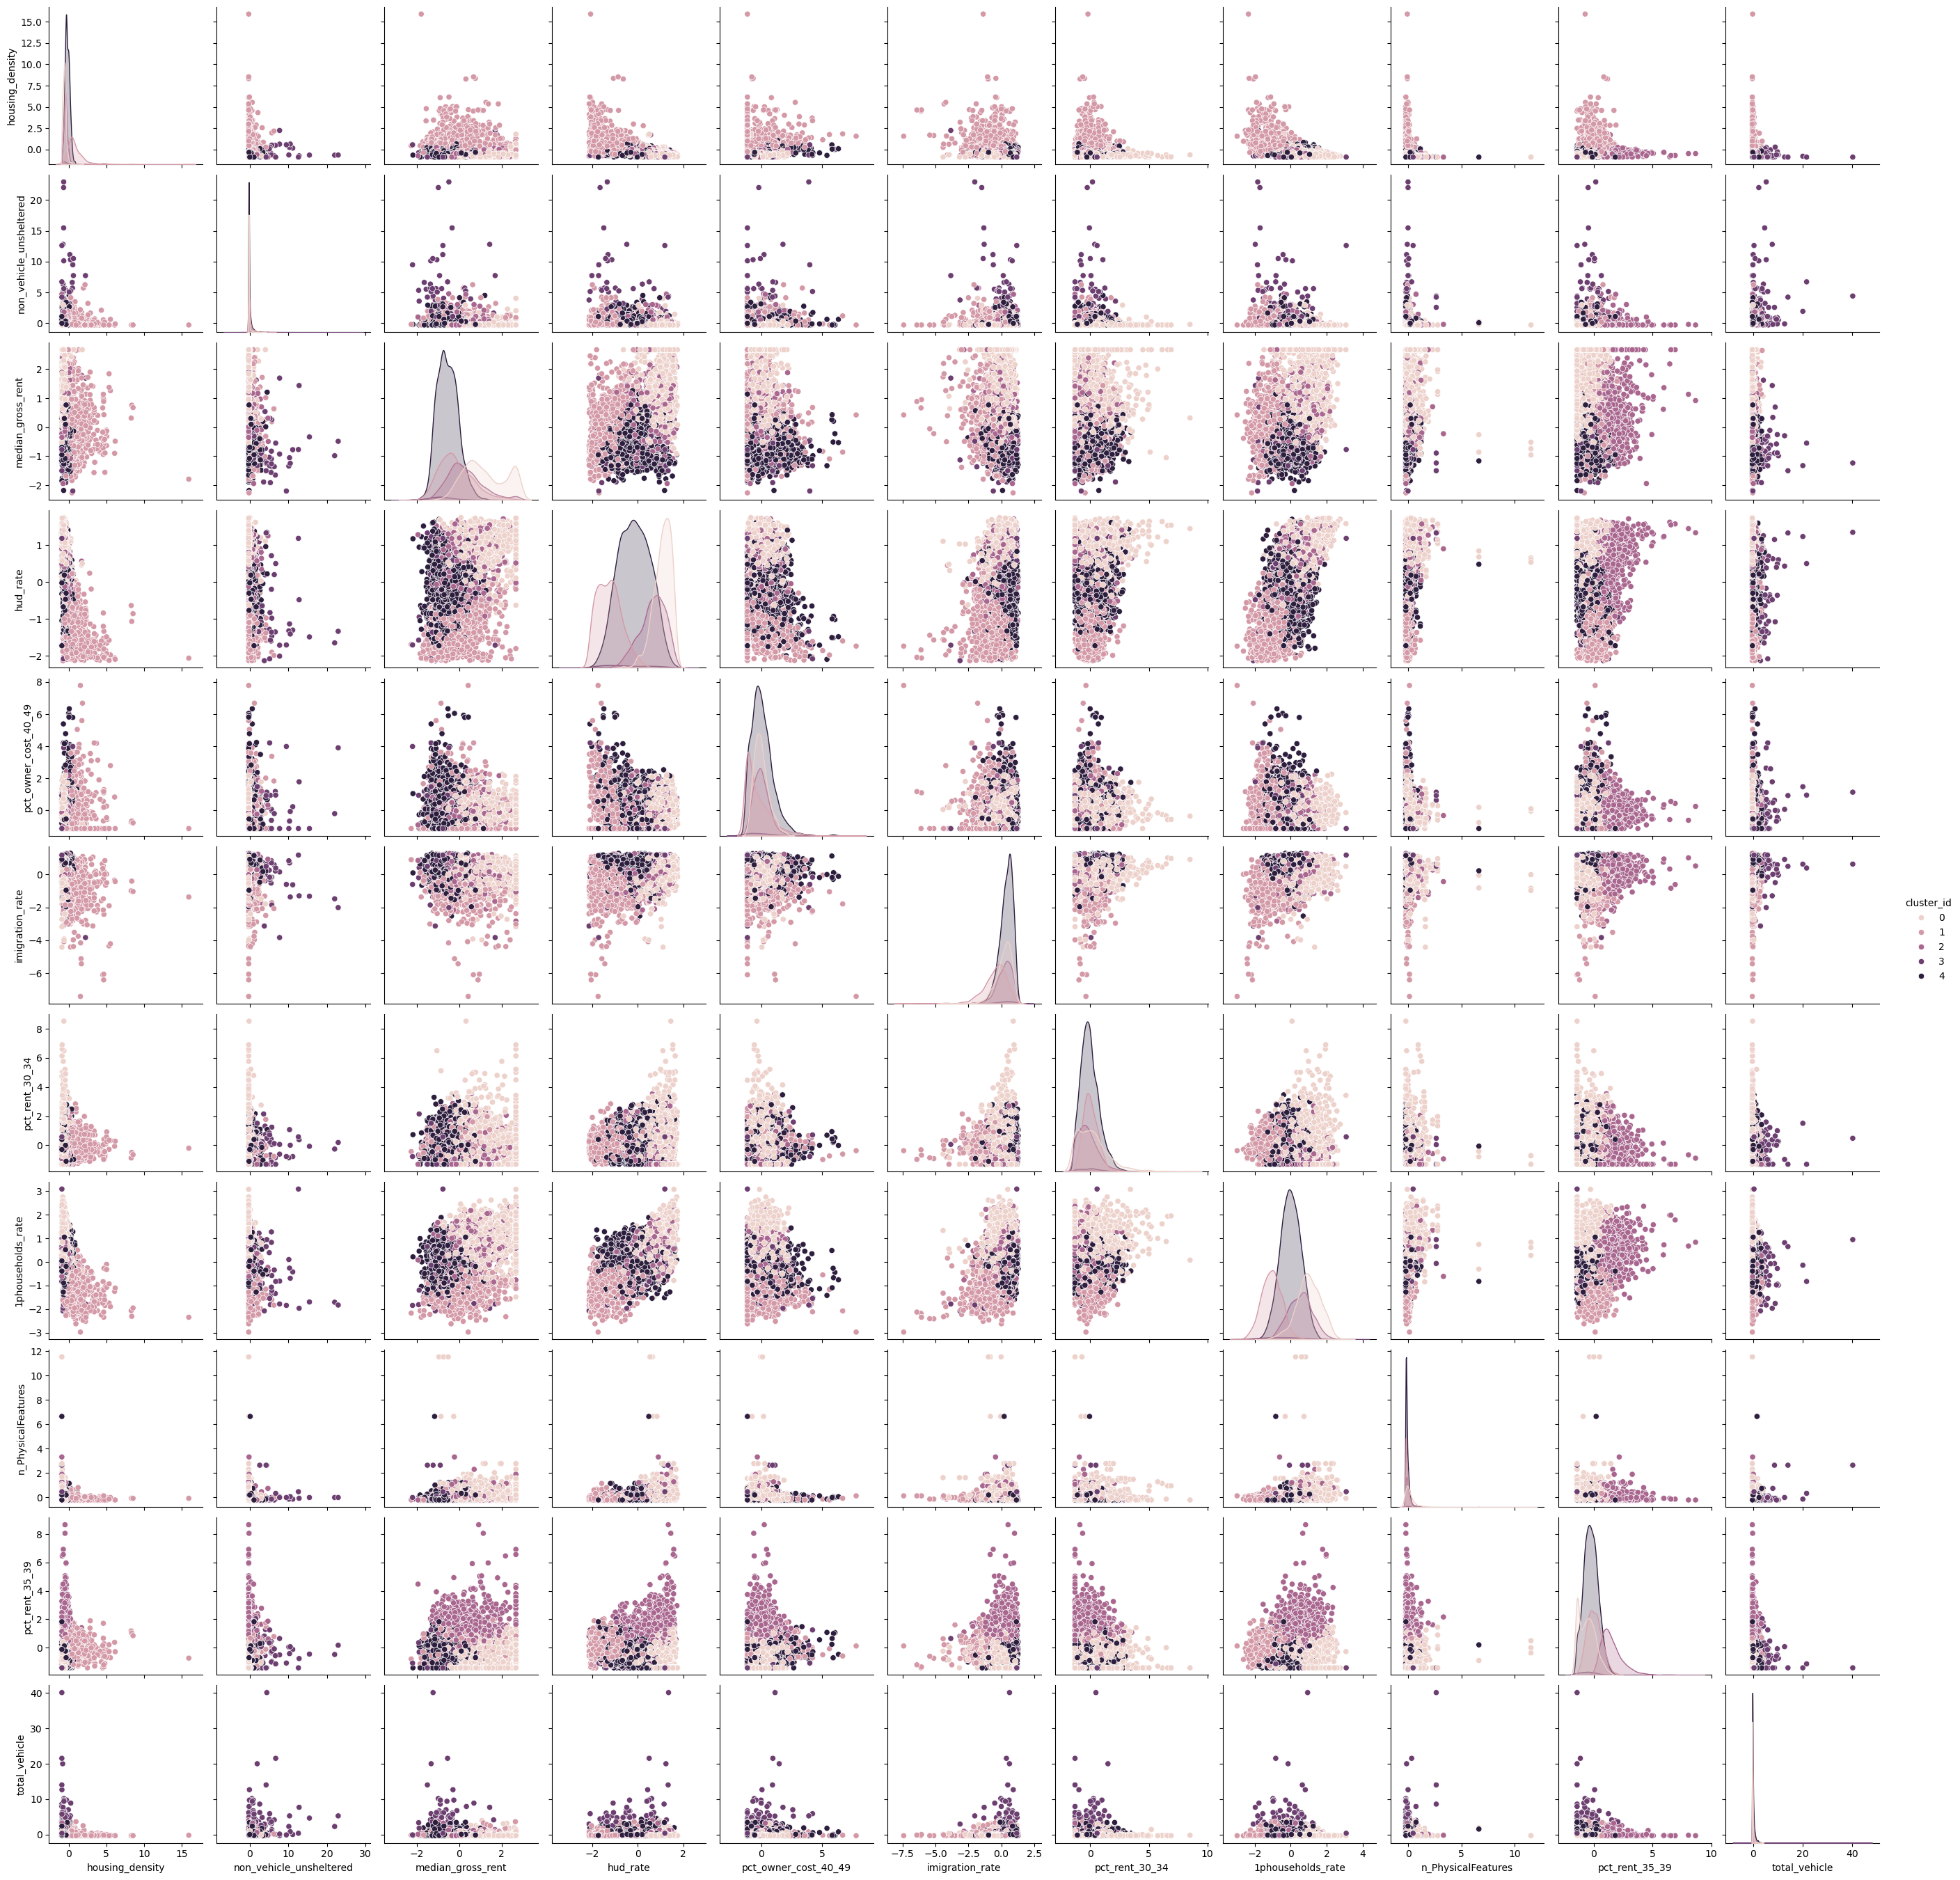

In [82]:
ax = sns.pairplot(merged_all_scaled, hue='cluster_id', )

### Mapping the clusters

In [83]:
merged_all['cluster_id'] = merged_all_scaled['cluster_id']

merged23_clustered = merged23.merge(
    merged_all[['GEOID', 'year', 'cluster_id']],
    on=['GEOID', 'year'],
    how='left'
)

In [85]:
merged23_clustered = merged23_clustered.merge(
    tracts23[['GEOID', 'geometry']], on='GEOID', how='left'
)

merged23_clustered = gpd.GeoDataFrame(
    merged23_clustered, geometry='geometry', crs=tracts23.crs
)

In [86]:
merged23_clustered.cluster_id = merged23_clustered.cluster_id.astype(str)
merged23_clustered.cluster_id = merged23_clustered.cluster_id.str.replace('.0', '')
merged23_clustered.cluster_id = merged23_clustered.cluster_id.str.replace('nan', 'No data')

[]

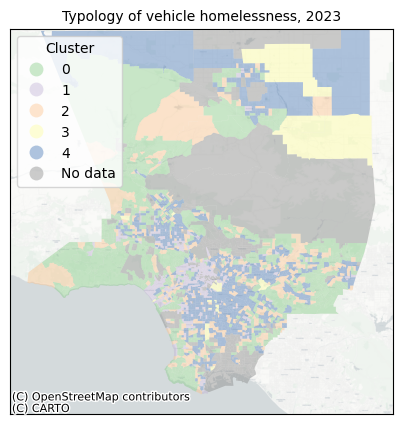

In [87]:
import contextily as ctx
from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list(
    'mycmap', [(0, '#7fc97f'), (0.2, '#beaed4'), (0.4, '#fdc086'), 
               (0.6, '#ffff99'), (0.8, '#386cb0'), (1.0, '0.5')])

fig, ax = plt.subplots(figsize=(5,5))
merged23_clustered.to_crs('EPSG:3857').plot('cluster_id', ax=ax, categorical=True, 
                                  legend=True, alpha=0.4, cmap=cmap,
                                  legend_kwds={'loc': 'upper left'})

# add a legend title
legend = ax.get_legend()
legend.set_title("Cluster", prop={'size':10} )

# all this is the same as before
ctx.add_basemap(ax, zoom=12, source=ctx.providers.CartoDB.Positron)
ax.set_title('Typology of vehicle homelessness, 2023', fontsize=10)                           
ax.set_ylim([3.98e6, 4.14e6])
ax.set_xticks([])
ax.set_yticks([])